In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import setmorph as sm
import matplotlib.ticker as ticker
sns.set_style("whitegrid")

In [2]:
paths = [
    ("arabic", "ar"),
    ("french", "fr"),
    ("ngkolmpu", "ng"),
    ("nuer", "nuer"),
    ("russian", "rus"),
    ("zenzontepec chatino", "zen"),
]

In [3]:
from functools import reduce


def multimerge(*dfs, **kwargs):
    return reduce(lambda left, right: pd.merge(left, right, **kwargs), dfs)

In [48]:
def collate_data(languages):
    paths = ["results/{lg}_analysis__values_per_word.csv",
             "results/{lg}_analysis__values.csv",
             "results/{lg}_analysis__formatives.csv",
             "src/setmorph/testdata/sample-{lg}-out.csv"]
    data = ([], [], [], [])
    for lg, key in languages:
        for path, dfs in zip(paths, data):
            if "analysis" in path:
                df = pd.read_csv(path.format(lg=key))
            else:
                df = sm.read_paradigms(path.format(lg=key))
            df["Language"] = lg
            dfs.append(df)

    vals_w, vals, forms, paradigms = tuple(pd.concat(dfs).reset_index() for dfs in data)

    # Some parsing to get lists
    forms["dist"] = forms["dist"].apply(lambda x: [fv.split(".") for fv in x.split(" ")])
    forms["exponence"] = forms["exponence"].fillna("").apply(lambda x: x.split(" "))

    # Add vals in word to paradigms
    paradigms = pd.merge(paradigms, forms[
        ["Language", "lexeme", "tier", "slot", "formative", "exponence", "vals"]],
                         on=["Language", "lexeme", "tier", "slot", "formative"])

    def restrict_to_word(row):
        c, e = row
        if e == "":
            return []
        vals = []
        exps = []
        for descr in e:
            descr = frozenset(descr.split("."))
            if descr <= c:
                vals.extend(descr)
                exps.append(descr)
        return pd.Series([sorted(set(exps)), sorted(set(vals))])

    paradigms[["exp_in_w", "vals_in_w"]] = paradigms.loc[:, ["cell", "exponence"]].apply(restrict_to_word,
                                                                      axis=1)
    paradigms.drop("vals", inplace=True, axis=1)
    return vals_w, vals, forms, paradigms

In [49]:
vals_w, vals, forms, paradigms = collate_data(paths)

In [50]:
plot_kwargs = dict(hue="Language", col="Language", height=8, aspect=1, discrete=True,
                   common_norm=False)

In [51]:

paradigms

,index,lexeme,cell,form,tier,slot,formative,Language,exponence,exp_in_w,vals_in_w
0,0,danā,"(p, ind, 2, f, act, prs)",t a d n uː n a,segmental,0,t,arabic,"[s.f, d.f, 2]",[(2)],[2]
1,5,danā,"(ind, 2, s, f, act, prs)",t a d n iː n a,segmental,0,t,arabic,"[s.f, d.f, 2]","[(s, f), (2)]","[2, f, s]"
2,10,danā,"(d, ind, 3, f, act, prs)",t a d n u w aː n i,segmental,0,t,arabic,"[s.f, d.f, 2]","[(d, f)]","[d, f]"
3,20,danā,"(ind, s, 3, f, act, prs)",t a d n uː,segmental,0,t,arabic,"[s.f, d.f, 2]","[(s, f)]","[f, s]"
4,23,danā,"(p, ind, 2, act, m, prs)",t a d n uː n a,segmental,0,t,arabic,"[s.f, d.f, 2]",[(2)],[2]
...,...,...,...,...,...,...,...,...,...,...,...
4514,345,ʔne⁰,(prog),n t e⁰ ʔ n e⁰,segmental,4,ʔne,zenzontepec chatino,[],[],[]
4515,338,ʔne⁰,(hab),t a⁰ l a⁰ ʔ n e⁰,segmental,1,t,zenzontepec chatino,"[prog, hab]",[(hab)],[hab]
4516,343,ʔne⁰,(prog),n t e⁰ ʔ n e⁰,segmental,1,t,zenzontepec chatino,"[prog, hab]",[(prog)],[prog]
4517,339,ʔne⁰,(hab),t a⁰ l a⁰ ʔ n e⁰,segmental,2,al,zenzontepec chatino,[hab],[(hab)],[hab]


In [39]:
forms

,index,lexeme,tier,slot,formative,dist,exponence,vals,|vals|,|exp|,cumulative,cumulative_cells,max_cumulation,maximum_possible_cumulation,Language
0,0,danā,segmental,0,j,"[[prs, act, ind, 3, m, p], [prs, act, ind, 3, ...","[m.3, 3.p]",3 m p,3,2,m.3 3.p,prs.act.ind.3.m.p prs.act.ind.3.f.p prs.act.in...,2,6,arabic
1,1,danā,segmental,0,n,"[[1, m/f, prs, act, ind, p]]",[1.p],1 p,2,1,1.p,1.m/f.prs.act.ind.p,2,6,arabic
2,2,danā,segmental,0,t,"[[2, prs, act, ind, s, f], [prs, act, ind, 3, ...","[s.f, d.f, 2]",2 d f s,4,3,s.f d.f,prs.act.ind.3.s.f prs.act.ind.3.f.d 2.prs.act....,2,6,arabic
3,3,danā,segmental,1,adn,"[[2, prs, act, ind, s, f], [prs, act, ind, 3, ...",[],NaN,0,0,NaN,NaN,0,6,arabic
4,4,danā,segmental,2,iː,"[[2, prs, act, ind, s, f]]",[2.s.f],2 f s,3,1,2.s.f,2.prs.act.ind.s.f,3,6,arabic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1111,145,ʔne⁰,segmental,3,e,[[prog]],[prog],prog,1,1,NaN,NaN,0,1,zenzontepec chatino
1112,146,ʔne⁰,segmental,4,ʔne,"[[prog], [pot], [hab], [cpl]]",[],NaN,0,0,NaN,NaN,0,1,zenzontepec chatino
1113,147,ʔne⁰,tone,0,⁰,[[hab]],[hab],hab,1,1,NaN,NaN,0,1,zenzontepec chatino
1114,148,ʔne⁰,tone,1,⁰,"[[prog], [hab], [cpl]]","[prog, hab, cpl]",cpl hab prog,3,3,NaN,NaN,0,1,zenzontepec chatino


In [31]:
forms[forms.Language == "french"]

,index,lexeme,tier,slot,formative,dist,exponence,vals,|vals|,|exp|,cumulative,cumulative_cells,max_cumulation,maximum_possible_cumulation,Language,fv
229,0,aller,segmental,0,al,"[[prs, 1pl], [inf], [prs, 2pl], [1sg, pst], [p...","[prs.1pl, pst, prs.2pl]",1pl 2pl prs pst,4,3,prs.2pl prs.1pl,prs.2pl prs.1pl,2,2,french,"(segmental, 0, al)"
230,1,aller,segmental,0,iʁ,"[[2sg, fut], [fut, 3pl], [1sg, fut], [fut, 3sg...",[fut],fut,1,1,NaN,NaN,0,2,french,"(segmental, 0, iʁ)"
231,2,aller,segmental,0,v,"[[1sg, prs], [prs, 3sg], [prs, 2sg], [prs, 3pl]]","[1sg.prs, prs.3sg, prs.2sg, prs.3pl]",1sg 2sg 3pl 3sg prs,5,4,1sg.prs prs.3sg prs.2sg prs.3pl,1sg.prs prs.3sg prs.2sg prs.3pl,2,2,french,"(segmental, 0, v)"
232,3,aller,segmental,1,E,"[[1sg, fut], [inf], [1sg, prs], [prs, 2pl], [1...","[inf, prs.2pl, 1sg, fut.2pl, pst.3pl]",1sg 2pl 3pl fut inf prs pst,7,5,pst.3pl prs.2pl fut.2pl,prs.2pl pst.3pl fut.2pl,2,2,french,"(segmental, 1, E)"
233,4,aller,segmental,1,a,"[[2sg, fut], [fut, 3sg], [prs, 3sg], [pst, 3sg...","[pst.2pl, pst.1pl, 3sg, 2sg]",1pl 2pl 2sg 3sg pst,5,4,pst.1pl pst.2pl,pst.1pl pst.2pl,2,2,french,"(segmental, 1, a)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469,240,touer,segmental,4,m,"[[pst, 1pl]]",[pst.1pl],1pl pst,2,1,pst.1pl,pst.1pl,2,2,french,"(segmental, 4, m)"
470,241,touer,segmental,4,t,"[[pst, 2pl]]",[pst.2pl],2pl pst,2,1,pst.2pl,pst.2pl,2,2,french,"(segmental, 4, t)"
471,242,touer,segmental,4,ɑ̃,"[[prs, ptcp]]",[ptcp],ptcp,1,1,NaN,NaN,0,2,french,"(segmental, 4, ɑ̃)"
472,243,touer,segmental,4,ɔ̃,"[[fut, 1pl], [fut, 3pl], [prs, 1pl]]","[fut.1pl, fut.3pl, prs.1pl]",1pl 3pl fut prs,4,3,fut.1pl fut.3pl prs.1pl,fut.1pl fut.3pl prs.1pl,2,2,french,"(segmental, 4, ɔ̃)"


In [32]:
paradigms

,index,lexeme,cell,form,tier,slot,formative,Language,exponence,vals_in_w
0,0,danā,"(p, ind, 2, f, act, prs)",t a d n uː n a,segmental,0,t,arabic,"[s.f, d.f, 2]",[2]
1,5,danā,"(ind, 2, s, f, act, prs)",t a d n iː n a,segmental,0,t,arabic,"[s.f, d.f, 2]","[2, f, s]"
2,10,danā,"(d, ind, 3, f, act, prs)",t a d n u w aː n i,segmental,0,t,arabic,"[s.f, d.f, 2]","[d, f]"
3,20,danā,"(ind, s, 3, f, act, prs)",t a d n uː,segmental,0,t,arabic,"[s.f, d.f, 2]","[f, s]"
4,23,danā,"(p, ind, 2, act, m, prs)",t a d n uː n a,segmental,0,t,arabic,"[s.f, d.f, 2]",[2]
...,...,...,...,...,...,...,...,...,...,...
4514,345,ʔne⁰,(prog),n t e⁰ ʔ n e⁰,segmental,4,ʔne,zenzontepec chatino,[],[]
4515,338,ʔne⁰,(hab),t a⁰ l a⁰ ʔ n e⁰,segmental,1,t,zenzontepec chatino,"[prog, hab]",[hab]
4516,343,ʔne⁰,(prog),n t e⁰ ʔ n e⁰,segmental,1,t,zenzontepec chatino,"[prog, hab]",[prog]
4517,339,ʔne⁰,(hab),t a⁰ l a⁰ ʔ n e⁰,segmental,2,al,zenzontepec chatino,[hab],[hab]


In [91]:

forms[forms.lexeme == "aller"]

,index,lexeme,tier,slot,formative,dist,exponence,vals,|vals|,|exp|,cumulative,cumulative_cells,max_cumulation,maximum_possible_cumulation,Language
229,0,aller,segmental,0,al,"[[pst, 3sg], [prs, ptcp], [2sg, pst], [1sg, ps...","[pst, prs.1pl, prs.2pl]",1pl 2pl prs pst,4,3,prs.1pl prs.2pl,prs.1pl prs.2pl,2,2,french
230,1,aller,segmental,0,iʁ,"[[fut, 1pl], [fut, 2pl], [2sg, fut], [1sg, fut...",[fut],fut,1,1,NaN,NaN,0,2,french
231,2,aller,segmental,0,v,"[[2sg, prs], [prs, 3pl], [1sg, prs], [3sg, prs]]","[2sg.prs, prs.3pl, 1sg.prs, 3sg.prs]",1sg 2sg 3pl 3sg prs,5,4,2sg.prs prs.3pl 1sg.prs 3sg.prs,2sg.prs prs.3pl 1sg.prs 3sg.prs,2,2,french
232,3,aller,segmental,1,E,"[[fut, 2pl], [1sg, pst], [1sg, fut], [inf], [1...","[fut.2pl, 1sg, inf, pst.3pl, prs.2pl]",1sg 2pl 3pl fut inf prs pst,7,5,fut.2pl pst.3pl prs.2pl,fut.2pl pst.3pl prs.2pl,2,2,french
233,4,aller,segmental,1,a,"[[pst, 3sg], [3sg, prs], [2sg, pst], [2sg, fut...","[pst.2pl, 3sg, pst.1pl, 2sg]",1pl 2pl 2sg 3sg pst,5,4,pst.2pl pst.1pl,pst.2pl pst.1pl,2,2,french
234,5,aller,segmental,2,m,"[[pst, 1pl]]",[pst.1pl],1pl pst,2,1,pst.1pl,pst.1pl,2,2,french
235,6,aller,segmental,2,t,"[[pst, 2pl]]",[pst.2pl],2pl pst,2,1,pst.2pl,pst.2pl,2,2,french
236,7,aller,segmental,2,ɑ̃,"[[prs, ptcp]]",[ptcp],ptcp,1,1,NaN,NaN,0,2,french
237,8,aller,segmental,2,ɔ̃,"[[fut, 1pl], [fut, 3pl], [prs, 1pl], [prs, 3pl]]","[fut.1pl, fut.3pl, prs.1pl, prs.3pl]",1pl 3pl fut prs,4,4,fut.1pl fut.3pl prs.1pl prs.3pl,fut.1pl fut.3pl prs.1pl prs.3pl,2,2,french
238,9,aller,segmental,2,ʁ,"[[pst, 3pl]]",[pst.3pl],3pl pst,2,1,pst.3pl,pst.3pl,2,2,french


# Traditional measures

Synthesis index: formatives / words

In [8]:
# Group formatives per word,
# Count rows in each group (=formatives)
# Then average across groups (=words)
word_identifiers = ["Language", "lexeme", "cell", "form"]
synthesis = paradigms.groupby(word_identifiers)["formative"].count()

synthesis.name = "synthesis"
synthesis_avg = synthesis.groupby(level=0).mean()
synthesis_avg

Language
arabic                 4.355311
french                 3.011364
ngkolmpu               5.009091
nuer                   3.208333
russian                4.094421
zenzontepec chatino    4.552632
Name: synthesis, dtype: float64

Fusionnal index:

1. feature-values / formatives

    Higher = more fusion.


In [9]:
# For each formative, ignoring stems
# Group per language
# Get number of values per formative
# Average per languages across formatives
no_stems = forms[forms["|vals|"] > 0]
fusion = no_stems.groupby("Language")["|vals|"].mean()
fusion.name = "fusion"
fusion

Language
arabic                 3.098039
french                 3.103604
ngkolmpu               2.872340
nuer                   1.000000
russian                3.400000
zenzontepec chatino    1.752212
Name: fusion, dtype: float64

Notes:

- Nuer average because we added "nom" but show only a partial paradigm...


# Affixation type


In [10]:
def affix_type(word):
    types = {}
    left_stem = False
    segs = word[word.tier == "segmental"]
    prev = None
    for k, row in segs.sort_values("slot").iterrows():
        if pd.isna(row["exponence"]):
            if left_stem:
                types[prev] = "infix"
            left_stem = True
            types[k] = "stem"
        else:
            types[k] = "suffix" if left_stem else "prefix"
        prev = k

    non_segs = word[word.tier != "segmental"]
    for k, row in non_segs.sort_values("slot").iterrows():
        if pd.isna(row["exponence"]):
            if not left_stem:
                left_stem = True
                types[k] = "stem"
            else:
                types[k] = None
        else:
            types[k] = "suprasegmental"

    if not left_stem:
        word["type"] = None
    else:
        word["type"] = word.index.map(types)
    return word

In [11]:

paradigms = paradigms.groupby(word_identifiers).apply(affix_type)

In [12]:
totals = paradigms[word_identifiers].drop_duplicates().groupby('Language').count().iloc[:,
         0]
totals.name = "words"
affix_types = paradigms.groupby(word_identifiers)["type"].value_counts()
affix_types.name = "data"
affix_types_avg = affix_types.groupby(["Language", "type"]).sum()
affix_types_avg = (affix_types_avg / totals).reset_index().pivot_table(index="Language",
                                                                       columns="type",
                                                                       values=0,
                                                                       fill_value=0)

In [13]:
affix_types = affix_types.reset_index().pivot_table(index=word_identifiers,
                                                    columns="type", values="data",
                                                    fill_value=0)

In [14]:
affix_types

type                                                                       infix  \
Language            lexeme  cell                     form                          
arabic              danā    (ind, 2, act, p, prs, f) t a d n uː n a            0   
                            (ind, 2, s, act, prs, f) t a d n iː n a            0   
                            (ind, d, act, prs, f, 3) t a d n u w aː n i        0   
                            (ind, s, act, prs, f, 3) t a d n uː                0   
                            (ind, m, 2, act, p, prs) t a d n uː n a            0   
...                                                                          ...   
zenzontepec chatino yu¹kų²ʔ (prog)                   n t e⁰ tʃ u¹ k ũ² ʔ      0   
                    ʔne⁰    (cpl)                    n k a⁰ ʔ n e⁰             0   
                            (pot)                    ʔ n e⁰                    0   
                            (hab)                    t a⁰ l a⁰ ʔ n e⁰          0   
                            (prog)                   n t e⁰ ʔ n e⁰             0   

type                                                                       prefix  \
Language            lexeme  cell                     form                           
arabic              danā    (ind, 2, act, p, prs, f) t a d n uː n a             1   
                            (ind, 2, s, act, prs, f) t a d n iː n a             1   
                            (ind, d, act, prs, f, 3) t a d n u w aː n i         1   
                            (ind, s, act, prs, f, 3) t a d n uː                 1   
                            (ind, m, 2, act, p, prs) t a d n uː n a             1   
...                                                                           ...   
zenzontepec chatino yu¹kų²ʔ (prog)                   n t e⁰ tʃ u¹ k ũ² ʔ       3   
                    ʔne⁰    (cpl)                    n k a⁰ ʔ n e⁰              3   
                            (pot)                    ʔ n e⁰                     0   
                            (hab)                    t a⁰ l a⁰ ʔ n e⁰           3   
                            (prog)                   n t e⁰ ʔ n e⁰              3   

type                                                                       stem  \
Language            lexeme  cell                     form                         
arabic              danā    (ind, 2, act, p, prs, f) t a d n uː n a           1   
                            (ind, 2, s, act, prs, f) t a d n iː n a           1   
                            (ind, d, act, prs, f, 3) t a d n u w aː n i       1   
                            (ind, s, act, prs, f, 3) t a d n uː               1   
                            (ind, m, 2, act, p, prs) t a d n uː n a           1   
...                                                                         ...   
zenzontepec chatino yu¹kų²ʔ (prog)                   n t e⁰ tʃ u¹ k ũ² ʔ     1   
                    ʔne⁰    (cpl)                    n k a⁰ ʔ n e⁰            1   
                            (pot)                    ʔ n e⁰                   1   
                            (hab)                    t a⁰ l a⁰ ʔ n e⁰         1   
                            (prog)                   n t e⁰ ʔ n e⁰            1   

type                                                                       suffix  \
Language            lexeme  cell                     form                           
arabic              danā    (ind, 2, act, p, prs, f) t a d n uː n a             3   
                            (ind, 2, s, act, prs, f) t a d n iː n a             3   
                            (ind, d, act, prs, f, 3) t a d n u w aː n i         3   
                            (ind, s, act, prs, f, 3) t a d n uː                 1   
                            (ind, m, 2, act, p, prs) t a d n uː n a             3   
...                                                                           ...   
zenzontepec chatino yu¹kų²ʔ (prog)       

# Microclasses


In [15]:
from setmorph import Formative

In [16]:
lexemes = paradigms[["lexeme", "Language"]].groupby("Language").nunique()

In [17]:
paradigms["formative-triple"] = paradigms[["tier", "slot", "formative"]].apply(
    lambda x: Formative(*x), axis=1)

In [18]:
paradigms.groupby("Language")["lexeme"].unique()

Language
arabic                 [danā, istaslama, istaḥrama, ittabaʿa, iḥtamal...
french                 [aller, apprendre, boire, croire, cuire, englo...
ngkolmpu               [DISROBE, EJECT, FINE_WORK, FOLLOW, HIDE, STAB...
nuer                   [ant, arrow, bead, belt, breeze, buffalo, butt...
russian                [butaf'or, f'ukus, k'asta, koklʲ'uʂ, kompl'ot,...
zenzontepec chatino    [a⁰chi¹, a⁰tzu⁰, a⁰ą⁰, hna⁰ʔ, ka⁰chi¹ʔ, la⁰kwi...
Name: lexeme, dtype: object

In [19]:
paradigms

,index,lexeme,cell,form,tier,slot,formative,Language,exponence,vals_in_w,type,formative-triple
0,0,danā,"(ind, 2, act, p, prs, f)",t a d n uː n a,segmental,0,t,arabic,s.f d.f 2,[2],prefix,"(segmental, 0, t)"
1,5,danā,"(ind, 2, s, act, prs, f)",t a d n iː n a,segmental,0,t,arabic,s.f d.f 2,"[2, f, s]",prefix,"(segmental, 0, t)"
2,10,danā,"(ind, d, act, prs, f, 3)",t a d n u w aː n i,segmental,0,t,arabic,s.f d.f 2,"[d, f]",prefix,"(segmental, 0, t)"
3,20,danā,"(ind, s, act, prs, f, 3)",t a d n uː,segmental,0,t,arabic,s.f d.f 2,"[f, s]",prefix,"(segmental, 0, t)"
4,23,danā,"(ind, m, 2, act, p, prs)",t a d n uː n a,segmental,0,t,arabic,s.f d.f 2,[2],prefix,"(segmental, 0, t)"
...,...,...,...,...,...,...,...,...,...,...,...,...
4514,345,ʔne⁰,(prog),n t e⁰ ʔ n e⁰,segmental,4,ʔne,zenzontepec chatino,NaN,[],stem,"(segmental, 4, ʔne)"
4515,338,ʔne⁰,(hab),t a⁰ l a⁰ ʔ n e⁰,segmental,1,t,zenzontepec chatino,prog hab,[hab],prefix,"(segmental, 1, t)"
4516,343,ʔne⁰,(prog),n t e⁰ ʔ n e⁰,segmental,1,t,zenzontepec chatino,prog hab,[prog],prefix,"(segmental, 1, t)"
4517,339,ʔne⁰,(hab),t a⁰ l a⁰ ʔ n e⁰,segmental,2,al,zenzontepec chatino,hab,[hab],prefix,"(segmental, 2, al)"


In [20]:
def microcl(group):
    def agg_microcl(group):
        return pd.Series({"microclasses": frozenset(group.index)})

    group.cell = group.cell.apply(".".join)
    para_affixes = group.pivot_table(index="lexeme", columns="cell",
                                     values="formative-triple", dropna=False,
                                     aggfunc=lambda x: " ".join(
                                         str(f) for f in sorted(x))).fillna("")
    cols = list(para_affixes.columns)
    mcs = para_affixes.groupby(cols, as_index=False).apply(agg_microcl)["microclasses"]
    assert mcs.apply(len).sum() == len(
        set(group.lexeme)), f"{mcs.apply(len).sum()} != {len(set(group.lexeme))}"
    return mcs


microclasses_detail = paradigms[~paradigms.exponence.isna()].groupby("Language").apply(
    microcl)
microclasses_detail

Language               
arabic               0       (ḥaraṯa)
                     1       (ʾaḥāla)
                     2      (iḵḍalla)
                     3         (danā)
                     4     (ittabaʿa)
                              ...    
zenzontepec chatino  9         (ʔne⁰)
                     10    (u¹na²na⁰)
                     11     (yu¹kų²ʔ)
                     12       (u²ne¹)
                     13        (a⁰ą⁰)
Name: microclasses, Length: 86, dtype: object

In [21]:
microclasses = microclasses_detail.groupby(level=0).apply(lambda g: g.shape[0])
microclasses

Language
arabic                  6
french                 16
ngkolmpu               10
nuer                   24
russian                16
zenzontepec chatino    14
Name: microclasses, dtype: int64

In [22]:

overall_averages = multimerge(affix_types_avg, fusion, synthesis_avg, microclasses,
                              #lexemes,
                              left_index=True, right_index=True)

In [23]:
overall_averages

,infix,prefix,stem,suffix,suprasegmental,fusion,synthesis,microclasses
Language,,,,,,,,
arabic,0.285714,0.930403,1.054945,2.084249,0.000000,3.098039,4.355311,6
french,0.090909,0.000000,1.045455,1.777273,0.000000,3.103604,3.011364,16
ngkolmpu,0.300000,1.854545,1.100000,1.754545,0.000000,2.872340,5.009091,10
nuer,0.291667,0.000000,1.229167,0.645833,0.687500,1.000000,3.208333,24
russian,0.107296,0.000000,1.008584,1.424893,0.562232,3.400000,4.094421,16
zenzontepec chatino,0.000000,2.302632,1.000000,0.000000,0.302632,1.752212,4.552632,14


How similar are languages ?

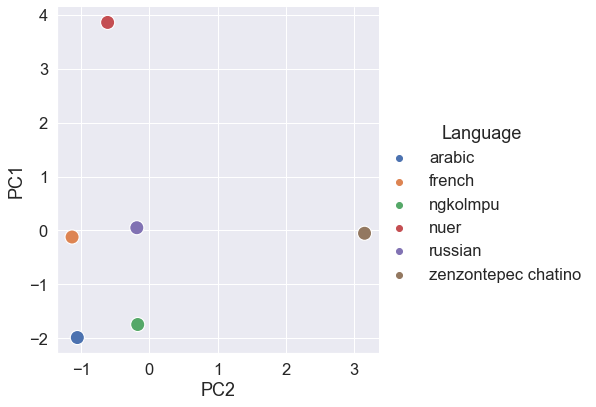

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

x = StandardScaler().fit_transform(overall_averages)
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(x)
principalDf = pd.DataFrame(data=principalComponents, columns=['PC1', 'PC2'],
                           index=overall_averages.index)

sns.set(font_scale=1.5)
sns.relplot(data=principalDf, x="PC2", y="PC1", hue="Language", height=6, aspect=1, s=200)

(0.0, 3.52)

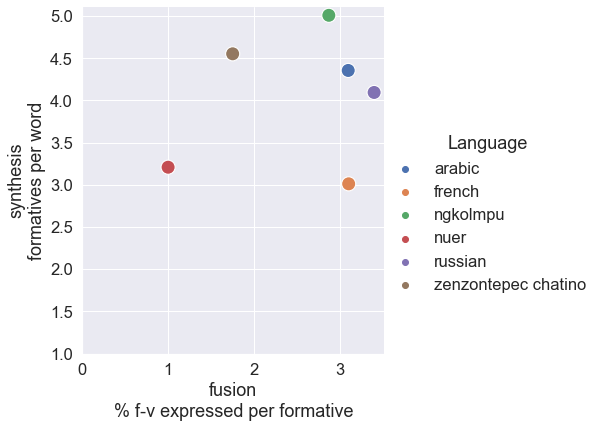

In [25]:

sns.set(font_scale=1.5)
sns.relplot(data=overall_averages, x="fusion", y="synthesis", hue="Language", height=6,
            aspect=1, s=200)
plt.xlabel("fusion\n% f-v expressed per formative")
plt.ylabel("synthesis\nformatives per word")
plt.ylim(1, None)
plt.xlim(0, None)

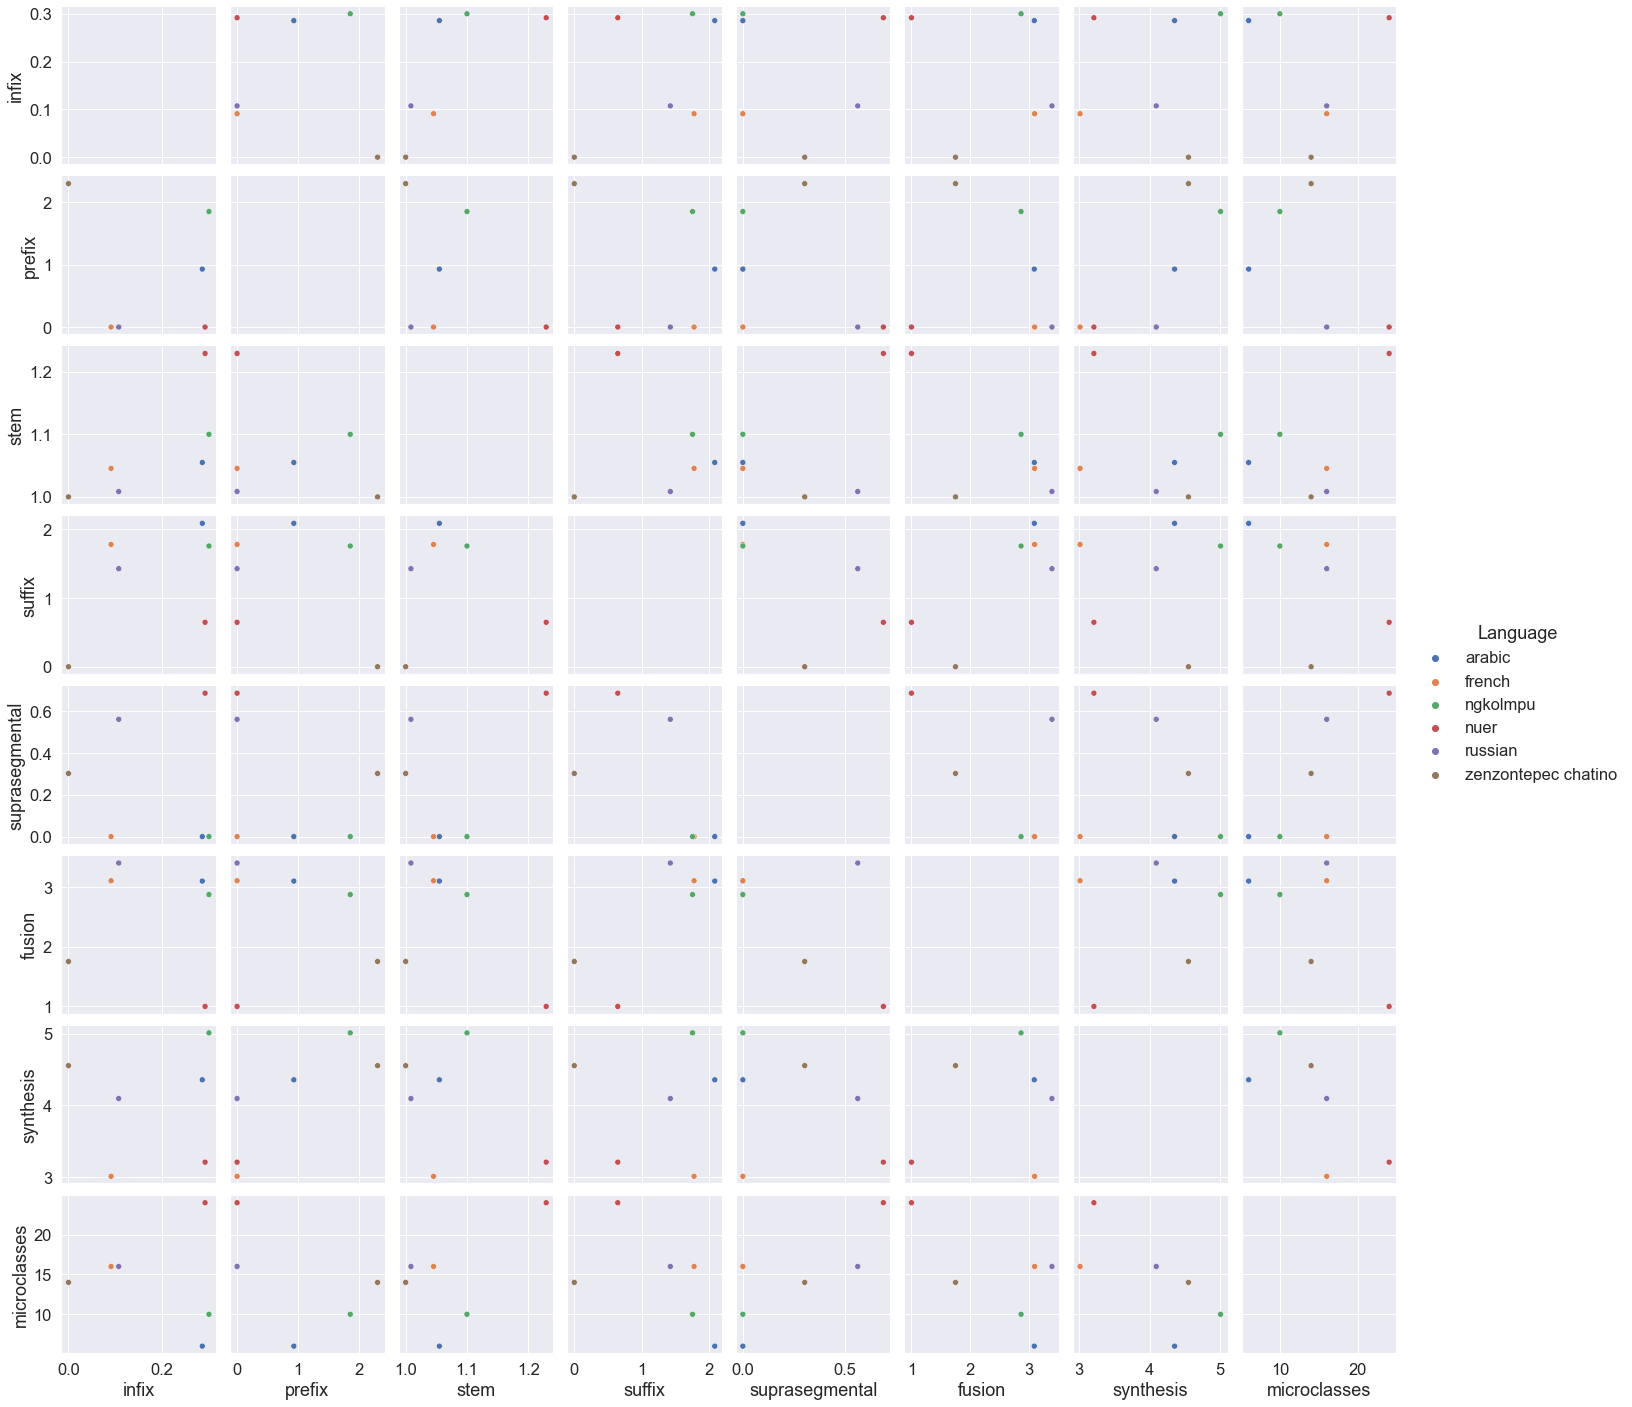

In [26]:
g = sns.pairplot(overall_averages.reset_index(), hue="Language", diag_kind="kde")

Now because this is all very coarse grained, we can do the same but per IC:

In [27]:
exemplars = list(microclasses_detail.apply(lambda x: list(x)[0]).values)

In [28]:
affix_types_per_IC = affix_types[affix_types.index.isin(exemplars, level=1)].groupby(
    ["Language", "lexeme"]).mean()

In [29]:
fusion_per_IC = no_stems[no_stems.lexeme.isin(exemplars)].groupby(["Language", "lexeme"])[
    "|vals|"].mean()
fusion_per_IC.name = "fusion"

In [30]:
synthesis_avg_per_IC = synthesis[synthesis.index.isin(exemplars, level=1)].groupby(
    level=[0, 1]).mean()

In [31]:
IC_size = pd.Series(
    dict(microclasses_detail.apply(lambda x: (list(x)[0], len(x))).values))

In [32]:

avgs_IC = multimerge(affix_types_per_IC, fusion_per_IC, synthesis_avg_per_IC,
                     left_index=True, right_index=True).reset_index()

In [33]:
avgs_IC

,Language,lexeme,infix,prefix,stem,suffix,suprasegmental,fusion,synthesis
0,arabic,danā,0.0,0.923077,1.000000,2.230769,0.00,3.444444,4.153846
1,arabic,ittabaʿa,0.0,1.000000,1.000000,2.076923,0.00,3.000000,4.076923
2,arabic,iḵḍalla,1.0,0.923077,1.153846,2.076923,0.00,3.000000,5.153846
3,arabic,saʾala,0.0,0.923077,1.000000,2.076923,0.00,3.100000,4.000000
4,arabic,ʾaḥāla,1.0,0.923077,2.000000,2.076923,0.00,3.083333,6.000000
...,...,...,...,...,...,...,...,...,...
79,zenzontepec chatino,u¹na²na⁰,0.0,2.000000,1.000000,0.000000,0.75,1.833333,4.750000
80,zenzontepec chatino,u⁰ti⁰ką⁰ʔ,0.0,2.750000,1.000000,0.000000,0.00,1.833333,4.750000
81,zenzontepec chatino,ya⁰la⁰ʔ,0.0,1.750000,1.000000,0.000000,0.25,1.600000,4.000000
82,zenzontepec chatino,yu¹kų²ʔ,0.0,2.000000,1.000000,0.000000,0.25,1.800000,4.250000


In [34]:
avgs_IC["IC_size"] = avgs_IC["lexeme"].map(IC_size)

In [35]:
avgs_IC

,Language,lexeme,infix,prefix,stem,suffix,suprasegmental,fusion,synthesis,IC_size
0,arabic,danā,0.0,0.923077,1.000000,2.230769,0.00,3.444444,4.153846,1
1,arabic,ittabaʿa,0.0,1.000000,1.000000,2.076923,0.00,3.000000,4.076923,1
2,arabic,iḵḍalla,1.0,0.923077,1.153846,2.076923,0.00,3.000000,5.153846,1
3,arabic,saʾala,0.0,0.923077,1.000000,2.076923,0.00,3.100000,4.000000,15
4,arabic,ʾaḥāla,1.0,0.923077,2.000000,2.076923,0.00,3.083333,6.000000,1
...,...,...,...,...,...,...,...,...,...,...
79,zenzontepec chatino,u¹na²na⁰,0.0,2.000000,1.000000,0.000000,0.75,1.833333,4.750000,1
80,zenzontepec chatino,u⁰ti⁰ką⁰ʔ,0.0,2.750000,1.000000,0.000000,0.00,1.833333,4.750000,1
81,zenzontepec chatino,ya⁰la⁰ʔ,0.0,1.750000,1.000000,0.000000,0.25,1.600000,4.000000,1
82,zenzontepec chatino,yu¹kų²ʔ,0.0,2.000000,1.000000,0.000000,0.25,1.800000,4.250000,1


(0.0, 4.5)

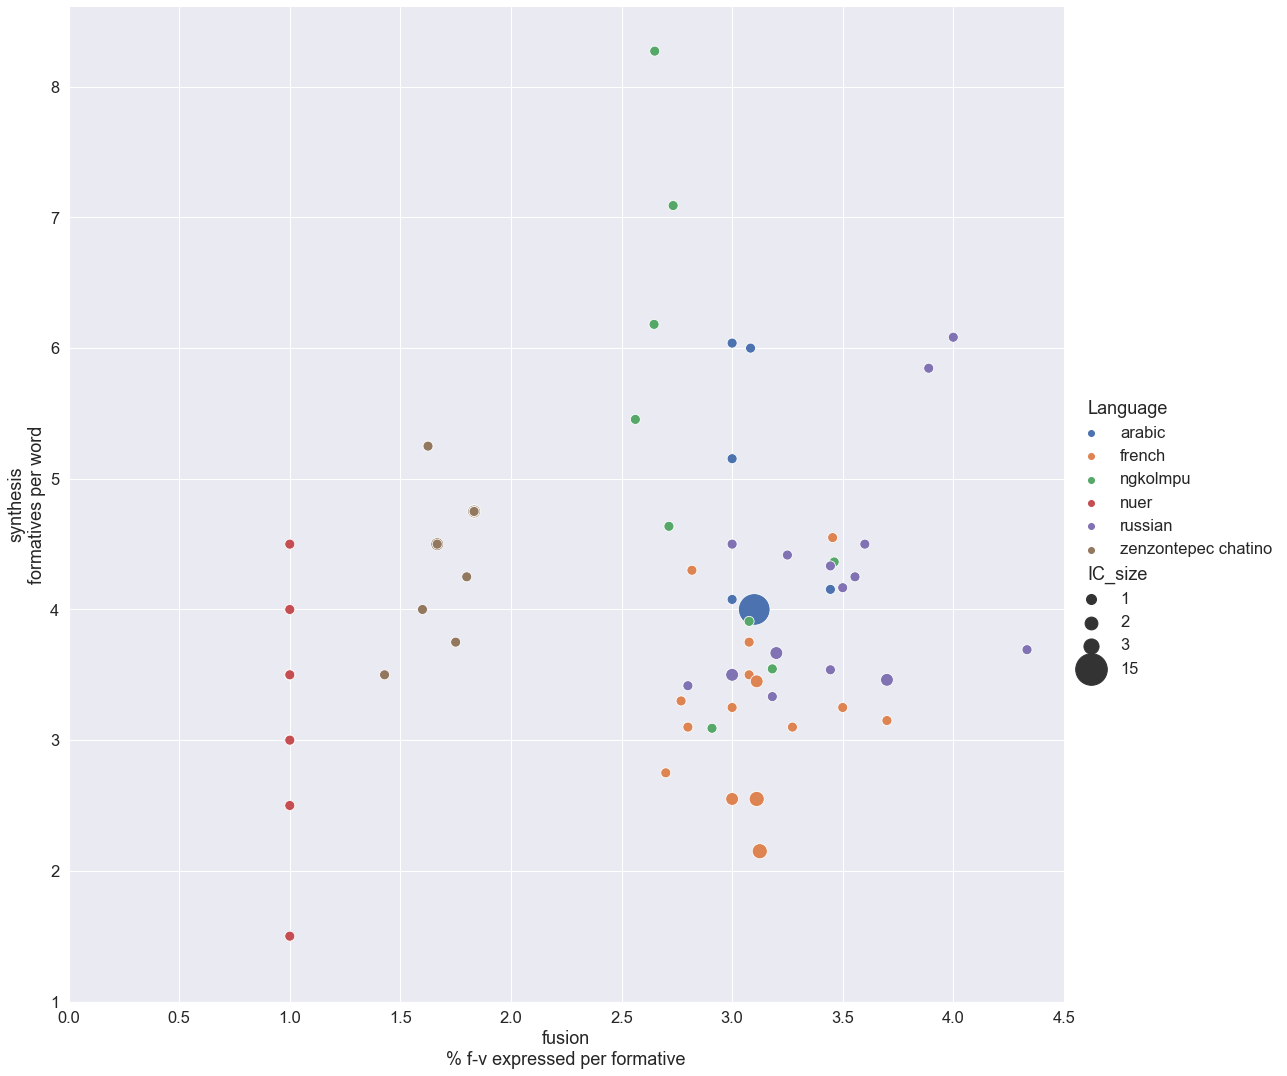

In [36]:

sns.set(font_scale=1.5)
sns.relplot(data=avgs_IC, x="fusion", y="synthesis", hue="Language", size="IC_size",
            height=15, aspect=1, sizes=(100, 1000))
plt.xlabel("fusion\n% f-v expressed per formative")
plt.ylabel("synthesis\nformatives per word")
plt.ylim(1, None)
plt.xlim(0, None)

- Hypothesis: Bigger microclasses are more canonical ?

In [38]:
avgs_IC

,Language,lexeme,infix,prefix,stem,suffix,suprasegmental,fusion,synthesis,IC_size
0,arabic,danā,0.0,0.923077,1.000000,2.230769,0.00,3.444444,4.153846,1
1,arabic,ittabaʿa,0.0,1.000000,1.000000,2.076923,0.00,3.000000,4.076923,1
2,arabic,iḵḍalla,1.0,0.923077,1.153846,2.076923,0.00,3.000000,5.153846,1
3,arabic,saʾala,0.0,0.923077,1.000000,2.076923,0.00,3.100000,4.000000,15
4,arabic,ʾaḥāla,1.0,0.923077,2.000000,2.076923,0.00,3.083333,6.000000,1
...,...,...,...,...,...,...,...,...,...,...
79,zenzontepec chatino,u¹na²na⁰,0.0,2.000000,1.000000,0.000000,0.75,1.833333,4.750000,1
80,zenzontepec chatino,u⁰ti⁰ką⁰ʔ,0.0,2.750000,1.000000,0.000000,0.00,1.833333,4.750000,1
81,zenzontepec chatino,ya⁰la⁰ʔ,0.0,1.750000,1.000000,0.000000,0.25,1.600000,4.000000,1
82,zenzontepec chatino,yu¹kų²ʔ,0.0,2.000000,1.000000,0.000000,0.25,1.800000,4.250000,1


# Overview


## Formatives

We first look at the number of values expressed per formative.
- 0 corresponds stems
- 1 corresponds to simple exponence
- 2+ corresponds to syncretism or cumulation

Of course, this is limited by the number of cells => For nuer we have only sg/pl so no more than 1 values can be expressed. It is always $n-1$ given $n$ cells.

In [39]:
plot_kwargs

{'hue': 'Language',
 'col': 'Language',
 'height': 8,
 'aspect': 1,
 'discrete': True,
 'common_norm': False}

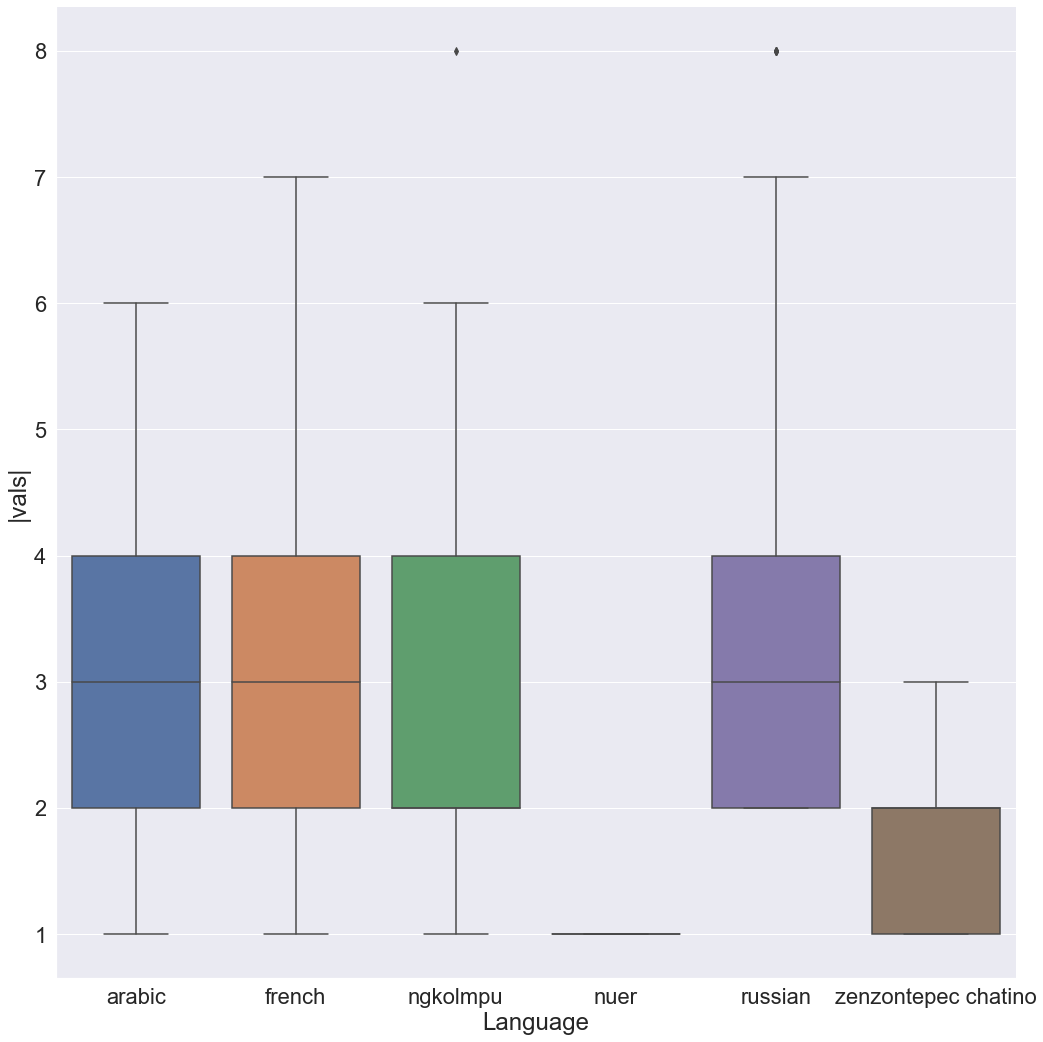

In [40]:

sns.set(font_scale=2)
sns.catplot(data=no_stems, x="Language", y="|vals|", kind="box", height=15, aspect=1)
sns.despine()

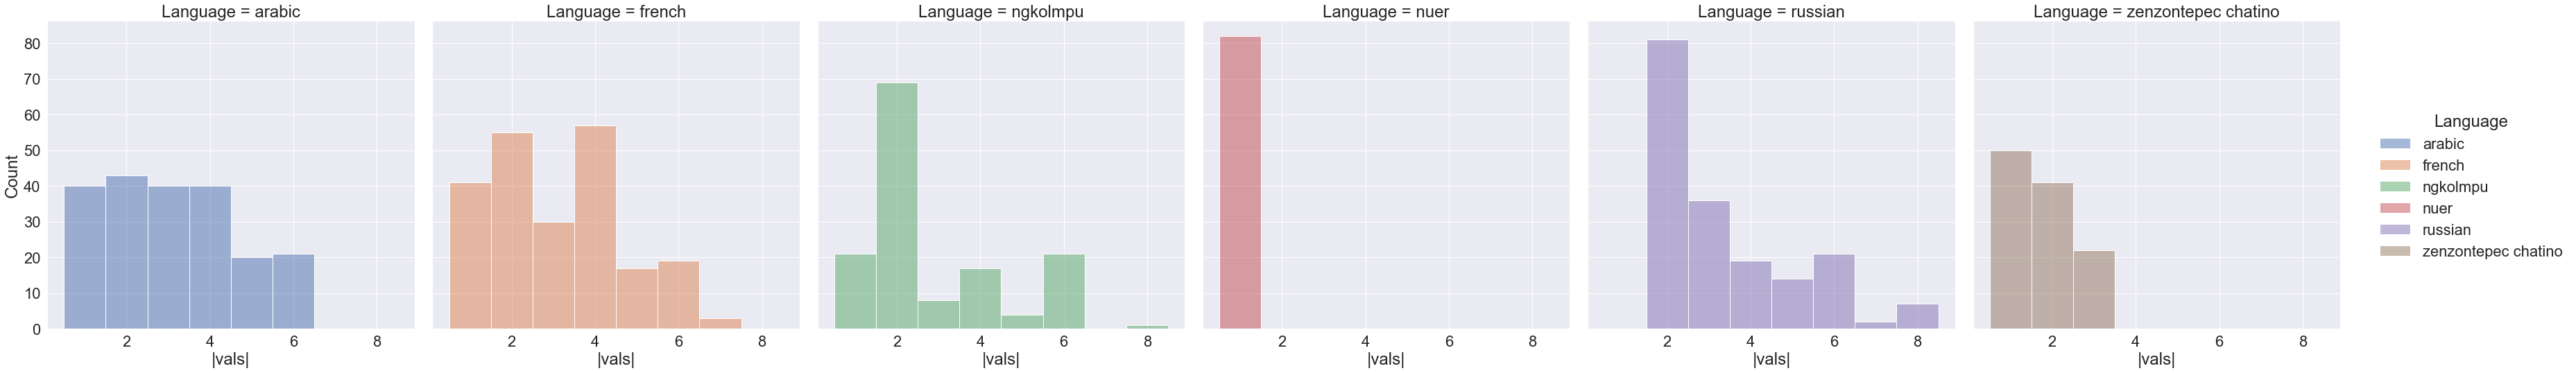

In [41]:

sns.set(font_scale=2)
sns.displot(no_stems, x="|vals|",binwidth=1,  **plot_kwargs)
sns.despine()

Syncretism:

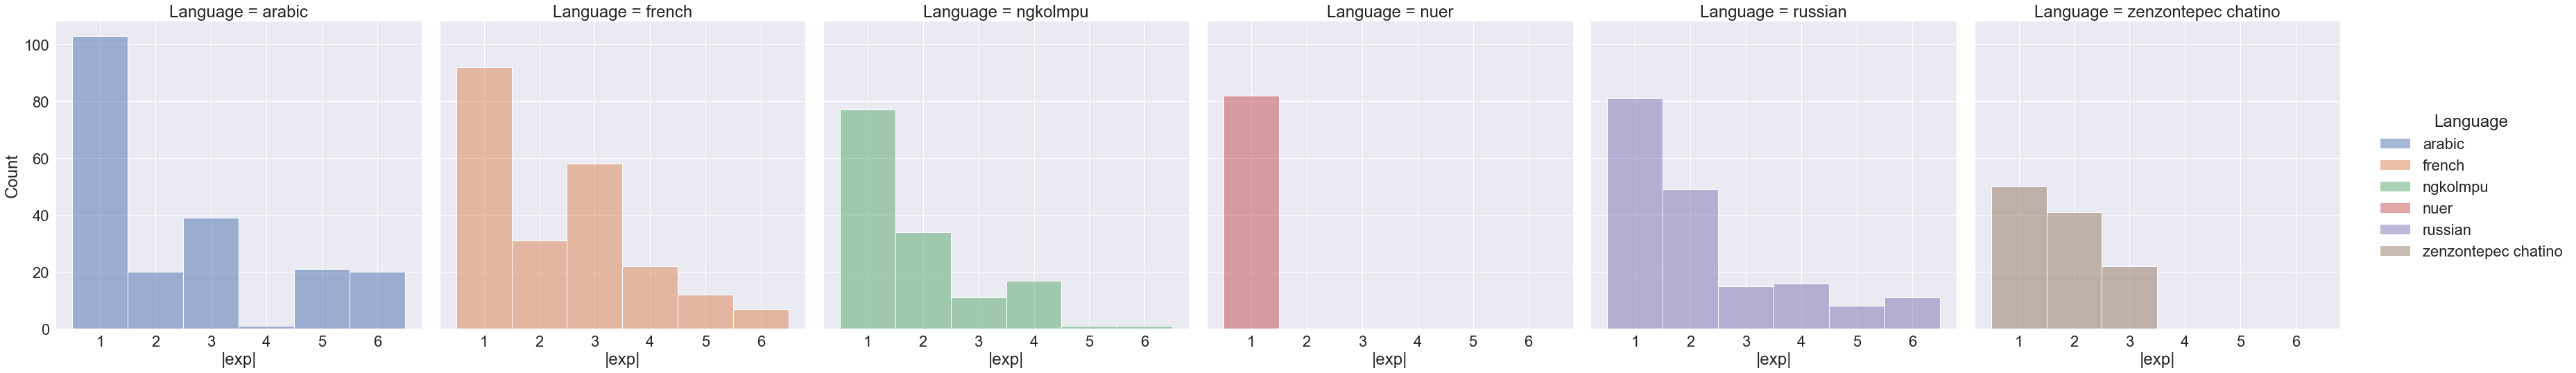

In [42]:

sns.displot(no_stems, x="|exp|",binwidth=1,  **plot_kwargs)
sns.despine()

Cumulation:

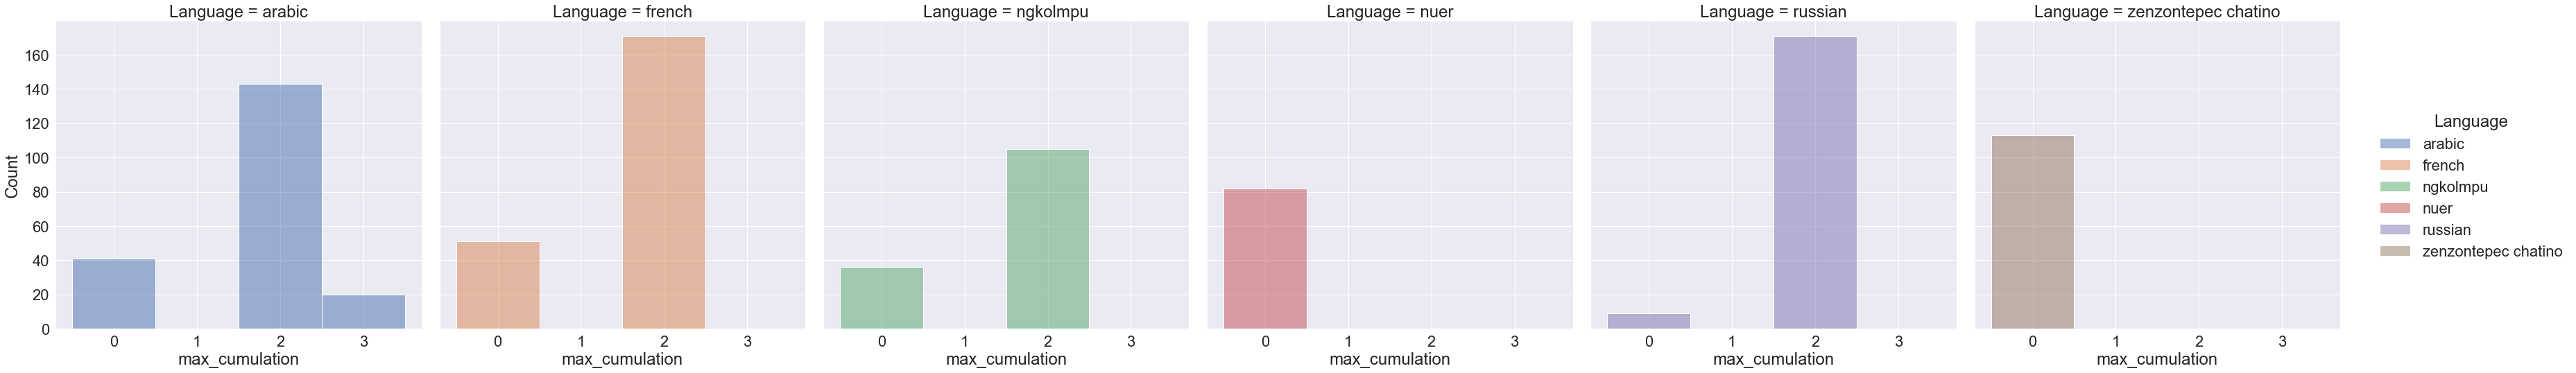

In [43]:

sns.displot(no_stems, x="max_cumulation",binwidth=1,  **plot_kwargs)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(base=1))
#sns.despine()

Both:

## Values

Overall, there is a deviation if there is not a single realization:

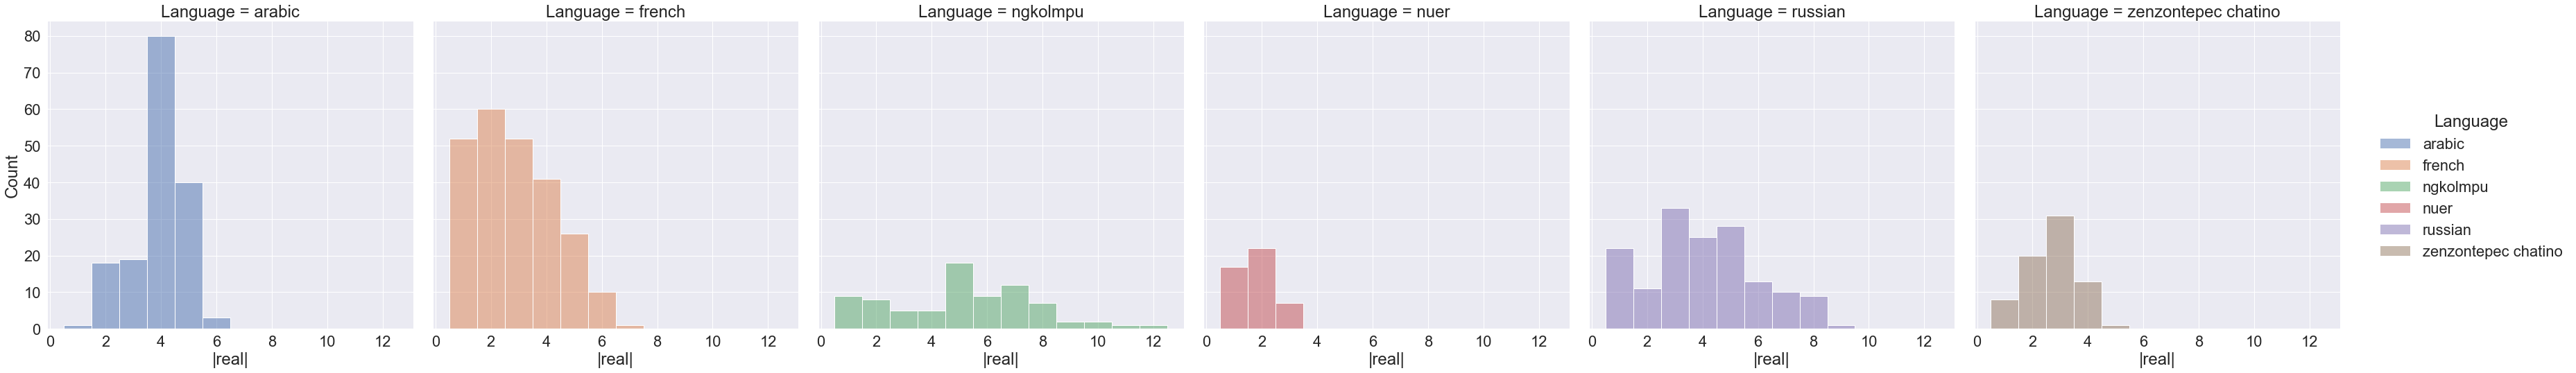

In [44]:

sns.displot(vals, x="|real|",binwidth=1,  **plot_kwargs)
sns.despine()

Allomorphy:

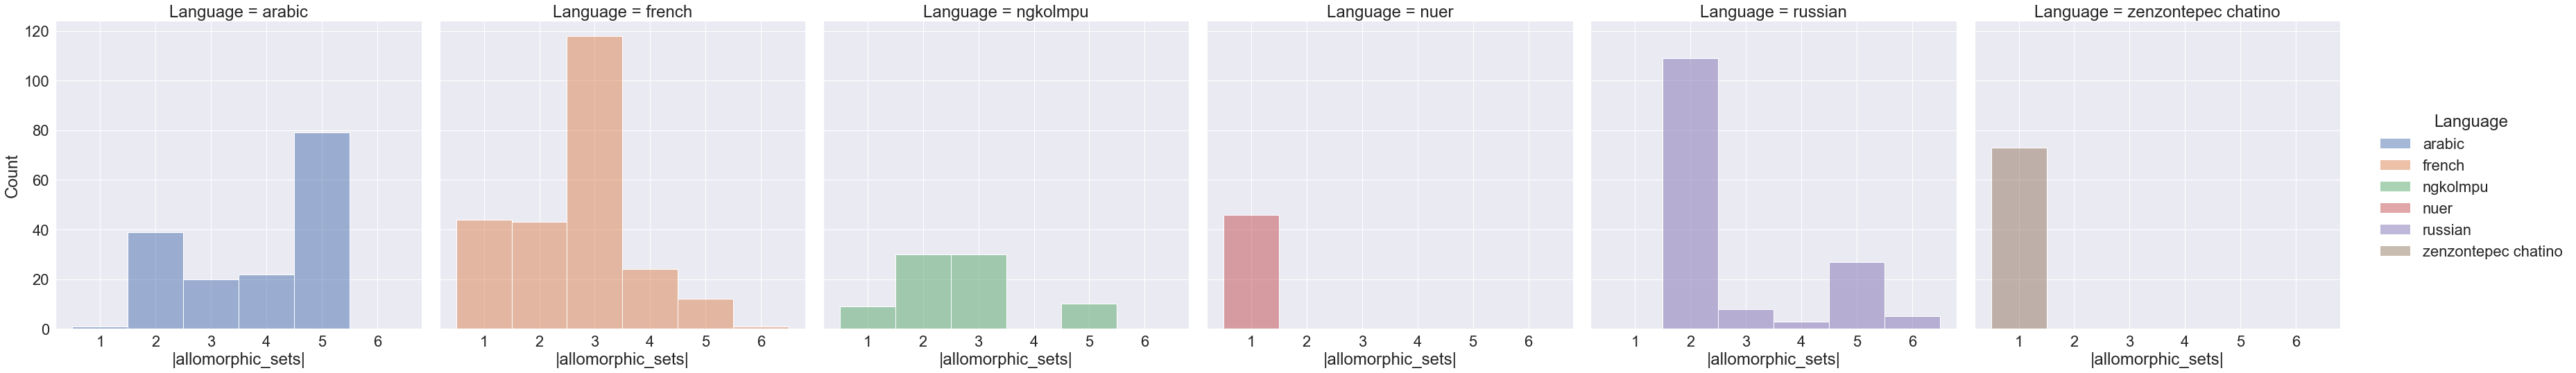

In [45]:
vals["|allomorphic_sets|"] = vals.allomorphic_sets.apply(lambda x: len(x.split(" ")))
sns.displot(vals, x="|allomorphic_sets|",binwidth=1,  **plot_kwargs)
sns.despine()

In [46]:
vals_w

,index,lexeme,form,cell,wordform,vals,real_w,|real_w|,Language
0,0,danā,n a d n uː,1.m/f.prs.act.ind.p,<segmental_0_n> <segmental_1_adn> <segmental_2...,1,<segmental_0_n> <segmental_2_uː>,2,arabic
1,1,danā,a d n uː,1.m/f.prs.act.ind.s,<segmental_1_adn> <segmental_2_uː>,1,<segmental_2_uː>,1,arabic
2,2,istaslama,n a s t a s l i m u,1.m/f.prs.act.ind.p,<segmental_0_n> <segmental_1_astaslim> <segmen...,1,<segmental_0_n> <segmental_4_u>,2,arabic
3,3,istaslama,a s t a s l i m u,1.m/f.prs.act.ind.s,<segmental_1_astaslim> <segmental_4_u>,1,<segmental_4_u>,1,arabic
4,4,istaḥrama,n a s t a ħ r i m u,1.m/f.prs.act.ind.p,<segmental_0_n> <segmental_1_astaħrim> <segmen...,1,<segmental_0_n> <segmental_4_u>,2,arabic
...,...,...,...,...,...,...,...,...,...
2416,68,u¹na²na⁰,n t e¹ n a² n a⁰,prog,<segmental_0_n> <segmental_1_t> <segmental_2_e...,prog,<segmental_0_n> <segmental_1_t> <segmental_2_e...,4,zenzontepec chatino
2417,69,u⁰ti⁰ką⁰ʔ,n t e⁰ t i⁰ k ã⁰ ʔ,prog,<segmental_0_n> <segmental_1_t> <segmental_2_e...,prog,<segmental_0_n> <segmental_1_t> <segmental_2_e>,3,zenzontepec chatino
2418,70,ya⁰la⁰ʔ,n t e⁰ j a⁰ l a⁰ ʔ,prog,<segmental_0_n> <segmental_1_tej> <segmental_2...,prog,<segmental_0_n> <segmental_1_tej> <tone_0_⁰>,3,zenzontepec chatino
2419,71,yu¹kų²ʔ,n t e⁰ tʃ u¹ k ũ² ʔ,prog,<segmental_0_n> <segmental_1_te> <segmental_2_...,prog,<segmental_0_n> <segmental_1_te> <segmental_2_...,4,zenzontepec chatino


Verbosity:

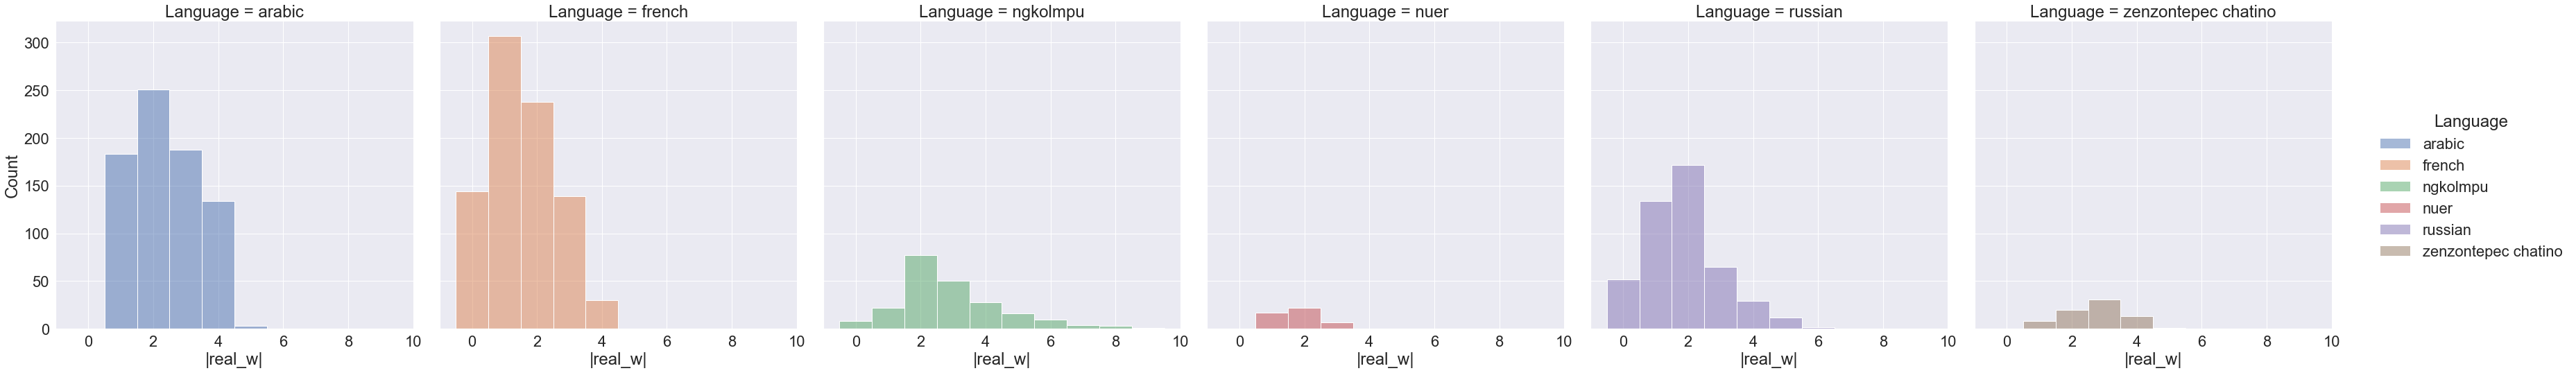

In [47]:
sns.displot(vals_w, x="|real_w|",binwidth=1, **plot_kwargs)
sns.despine()

# New measures

In [48]:
fr_features = sm.read_features("src/setmorph/testdata/fr_features.csv")
ng_features = sm.read_features("src/setmorph/testdata/ng_features.csv")
ar_features = sm.read_features("src/setmorph/testdata/ar_features.csv")
nuer_features = sm.read_features("src/setmorph/testdata/nuer_features.csv")
rus_features = sm.read_features("src/setmorph/testdata/rus_features.csv")
zen_features = sm.read_features("src/setmorph/testdata/zen_features.csv")

In [49]:
vals_IC = vals[vals.lexeme.isin(exemplars)]

In [50]:
paradigms_IC = paradigms[paradigms.lexeme.isin(exemplars)]
vals_w_IC = vals_w[vals_w.lexeme.isin(exemplars)]
no_stems_IC = no_stems[no_stems.lexeme.isin(exemplars)]

In [51]:
total_vals = vals_IC.groupby(["Language", "lexeme"])["vals"].count()

In [52]:
total_forms = no_stems_IC.groupby(["Language", "lexeme"])["index"].count().rename("total_formatives")
total_forms

Language             lexeme   
arabic               danā          9
                     ittabaʿa     11
                     iḵḍalla      11
                     saʾala       10
                     ʾaḥāla       12
                                  ..
zenzontepec chatino  u¹na²na⁰      6
                     u⁰ti⁰ką⁰ʔ     6
                     ya⁰la⁰ʔ       5
                     yu¹kų²ʔ       5
                     ʔne⁰          8
Name: total_formatives, Length: 86, dtype: int64

## For formatives

### Overview Per IC

In [53]:
vals_IC

,index,vals,lexeme,real,|real|,allomorphic_sets,Language,|allomorphic_sets|
0,0,1,danā,<segmental_0_n> <segmental_2_uː>,2,<segmental_0_n>-<segmental_2_uː> <segmental_2_uː>,arabic,2
3,3,1,ittabaʿa,<segmental_0_n> <segmental_0_ʔ> <segmental_4_u>,3,<segmental_0_n>-<segmental_4_u> <segmental_0_ʔ...,arabic,2
6,6,1,iḵḍalla,<segmental_0_n> <segmental_6_u>,2,<segmental_0_n>-<segmental_6_u> <segmental_6_u>,arabic,2
10,10,1,saʾala,<segmental_0_n> <segmental_4_u>,2,<segmental_0_n>-<segmental_4_u> <segmental_4_u>,arabic,2
17,17,1,ʾaḥāla,<segmental_0_n> <segmental_6_u>,2,<segmental_0_n>-<segmental_6_u> <segmental_6_u>,arabic,2
...,...,...,...,...,...,...,...,...
748,68,prog,u¹na²na⁰,<segmental_0_n> <segmental_1_t> <segmental_2_e...,4,<segmental_0_n>-<segmental_1_t>-<segmental_2_e...,zenzontepec chatino,1
749,69,prog,u⁰ti⁰ką⁰ʔ,<segmental_0_n> <segmental_1_t> <segmental_2_e>,3,<segmental_0_n>-<segmental_1_t>-<segmental_2_e>,zenzontepec chatino,1
750,70,prog,ya⁰la⁰ʔ,<segmental_0_n> <segmental_1_tej> <tone_0_⁰>,3,<segmental_0_n>-<segmental_1_tej>-<tone_0_⁰>,zenzontepec chatino,1
751,71,prog,yu¹kų²ʔ,<segmental_0_n> <segmental_1_te> <segmental_2_...,4,<segmental_0_n>-<segmental_1_te>-<segmental_2_...,zenzontepec chatino,1


In [54]:
no_stems_IC["|cumulative|"] = no_stems_IC["cumulative"].apply(lambda x: len(x.split(" ")) if not pd.isna(x) else 0)

/tmp/ipykernel_46655/295649709.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_stems_IC["|cumulative|"] = no_stems_IC["cumulative"].apply(lambda x: len(x.split(" ")) if not pd.isna(x) else 0)


In [55]:
coarse = multimerge(
    (vals_IC[vals_IC["|allomorphic_sets|"] > 1].groupby(["Language", "lexeme"])["vals"].count() / total_vals * 100).rename("allomorphic_prop"),
    # Proportion of the total values
    vals_IC.groupby(["Language", "lexeme"])["|allomorphic_sets|"].mean().rename("allomorphic_size"),

    (vals_w_IC[vals_w_IC["|real_w|"] > 1].groupby(["Language", "lexeme"])["vals"].count() / vals_w_IC.groupby(["Language", "lexeme"])["vals"].count() * 100).rename("verbose_prop"),
    # Why is this above 100%

    vals_w_IC.groupby(["Language", "lexeme"])["|real_w|"].mean().rename("verbose_size"),

    vals_IC.groupby(["Language", "lexeme"])["|real|"].mean().rename("|real|"),
    no_stems_IC.groupby(["Language", "lexeme"])["|vals|"].mean().rename("|vals|"),

    (vals_w_IC[vals_w_IC["|real_w|"] == 0].groupby(["Language", "lexeme"])["vals"].count() / total_vals * 100 ).rename("zero_vals_prop"),

    (no_stems_IC[no_stems_IC["|exp|"] > 1].groupby(["Language", "lexeme"])["|exp|"].count() / no_stems_IC.groupby(["Language", "lexeme"])["|exp|"].count() * 100).rename("syncretic_prop"),
    no_stems_IC.groupby(["Language", "lexeme"])["|exp|"].mean().rename("exp_size"),
    (no_stems_IC[no_stems_IC["|cumulative|"] > 1].groupby(["Language", "lexeme"])["|cumulative|"].count() / total_forms * 100).rename("cumulative_prop_of_formatives"),
    (no_stems_IC.groupby(["Language", "lexeme"])["|cumulative|"].sum() / no_stems_IC.groupby(["Language", "lexeme"])["|exp|"].sum() * 100).rename("cumulative_prop_of_exp"),
    (no_stems_IC.groupby(["Language", "lexeme"])["max_cumulation"].mean()).rename("max_cumulation_size"),

    left_index=True, right_index=True, how="outer").fillna(0)


In [56]:
coarse_IC_size = coarse.index.get_level_values(1).map(IC_size)

In [57]:
coarse

allomorphic_prop  allomorphic_size  \
Language            lexeme                                          
arabic              danā             100.000000          3.625000   
                    ittabaʿa         100.000000          4.000000   
                    iḵḍalla          100.000000          3.875000   
                    saʾala           100.000000          3.875000   
                    ʾaḥāla            88.888889          3.555556   
...                                         ...               ...   
zenzontepec chatino u¹na²na⁰           0.000000          1.000000   
                    u⁰ti⁰ką⁰ʔ          0.000000          1.000000   
                    ya⁰la⁰ʔ            0.000000          1.000000   
                    yu¹kų²ʔ            0.000000          1.000000   
                    ʔne⁰               0.000000          1.000000   

                               verbose_prop  verbose_size    |real|    |vals|  \
Language            lexeme                                                      
arabic              danā          80.555556      2.555556  3.875000  3.444444   
                    ittabaʿa      80.555556      2.388889  4.125000  3.000000   
                    iḵḍalla       75.000000      2.444444  4.125000  3.000000   
                    saʾala        75.000000      2.333333  3.875000  3.100000   
                    ʾaḥāla        76.923077      2.666667  4.111111  3.083333   
...                                     ...           ...       ...       ...   
zenzontepec chatino u¹na²na⁰     100.000000      3.666667  3.666667  1.833333   
                    u⁰ti⁰ką⁰ʔ    100.000000      2.750000  2.750000  1.833333   
                    ya⁰la⁰ʔ       75.000000      2.000000  2.000000  1.600000   
                    yu¹kų²ʔ       75.000000      2.250000  2.250000  1.800000   
                    ʔne⁰         100.000000      4.333333  4.333333  1.625000   

                               zero_vals_prop  syncretic_prop  exp_size  \
Language            lexeme                                                
arabic              danā                  0.0       55.555556  2.777778   
                    ittabaʿa              0.0       45.454545  2.272727   
                    iḵḍalla               0.0       45.454545  2.272727   
                    saʾala                0.0       50.000000  2.400000   
                    ʾaḥāla                0.0       50.000000  2.416667   
...                                       ...             ...       ...   
zenzontepec chatino u¹na²na⁰              0.0       50.000000  1.833333   
                    u⁰ti⁰ką⁰ʔ             0.0       66.666667  1.833333   
                    ya⁰la⁰ʔ               0.0       40.000000  1.600000   
                    yu¹kų²ʔ               0.0       40.000000  1.800000   
                    ʔne⁰                  0.0       50.000000  1.625000   

                               cumulative_prop_of_formatives  \
Language            lexeme                                     
arabic              danā                           55.555556   
                    ittabaʿa                       45.454545   
                    iḵḍalla                        45.454545   
                    saʾala                         50.000000   
                    ʾaḥāla                         41.666667   
...                                                      ...   
zenzontepec chatino u¹na²na⁰                        0.000000   
                    u⁰ti⁰ką⁰ʔ                       0.000000   
                    ya⁰la⁰ʔ                         0.000000   
                    yu¹kų²ʔ                         0.000000   
                    ʔne⁰                            0.000000   

                               cumulative_prop_of_exp  max_cumulation_size  
Language            lexeme                                                  
arabic              danā                    76.000000             1.666667  
                    ittabaʿa           

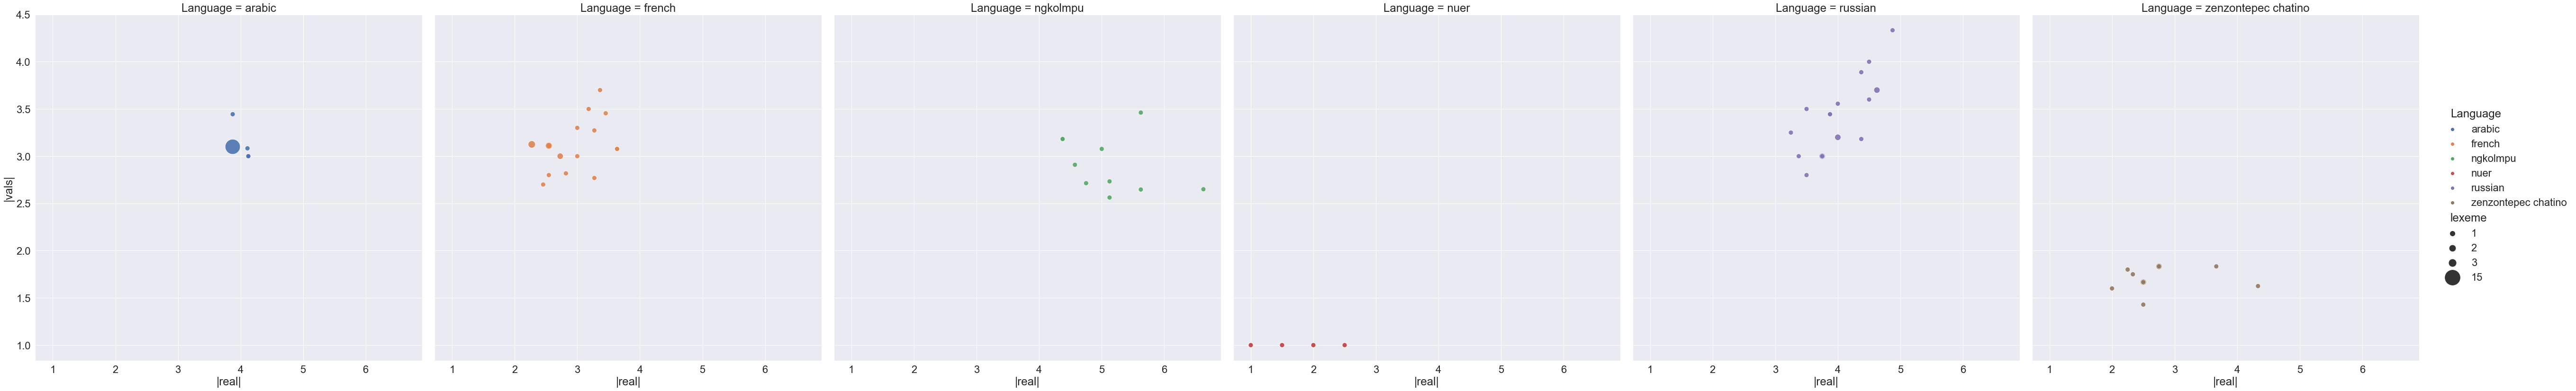

In [68]:
sns.relplot(data=coarse, x="|real|",y="|vals|", hue="Language", col="Language", size=coarse_IC_size,
            height=12, aspect=1, sizes=(100, 1000), alpha=0.9)
sns.despine()

In [59]:
coarse

allomorphic_prop  allomorphic_size  \
Language            lexeme                                          
arabic              danā             100.000000          3.625000   
                    ittabaʿa         100.000000          4.000000   
                    iḵḍalla          100.000000          3.875000   
                    saʾala           100.000000          3.875000   
                    ʾaḥāla            88.888889          3.555556   
...                                         ...               ...   
zenzontepec chatino u¹na²na⁰           0.000000          1.000000   
                    u⁰ti⁰ką⁰ʔ          0.000000          1.000000   
                    ya⁰la⁰ʔ            0.000000          1.000000   
                    yu¹kų²ʔ            0.000000          1.000000   
                    ʔne⁰               0.000000          1.000000   

                               verbose_prop  verbose_size    |real|    |vals|  \
Language            lexeme                                                      
arabic              danā          80.555556      2.555556  3.875000  3.444444   
                    ittabaʿa      80.555556      2.388889  4.125000  3.000000   
                    iḵḍalla       75.000000      2.444444  4.125000  3.000000   
                    saʾala        75.000000      2.333333  3.875000  3.100000   
                    ʾaḥāla        76.923077      2.666667  4.111111  3.083333   
...                                     ...           ...       ...       ...   
zenzontepec chatino u¹na²na⁰     100.000000      3.666667  3.666667  1.833333   
                    u⁰ti⁰ką⁰ʔ    100.000000      2.750000  2.750000  1.833333   
                    ya⁰la⁰ʔ       75.000000      2.000000  2.000000  1.600000   
                    yu¹kų²ʔ       75.000000      2.250000  2.250000  1.800000   
                    ʔne⁰         100.000000      4.333333  4.333333  1.625000   

                               zero_vals_prop  syncretic_prop  exp_size  \
Language            lexeme                                                
arabic              danā                  0.0       55.555556  2.777778   
                    ittabaʿa              0.0       45.454545  2.272727   
                    iḵḍalla               0.0       45.454545  2.272727   
                    saʾala                0.0       50.000000  2.400000   
                    ʾaḥāla                0.0       50.000000  2.416667   
...                                       ...             ...       ...   
zenzontepec chatino u¹na²na⁰              0.0       50.000000  1.833333   
                    u⁰ti⁰ką⁰ʔ             0.0       66.666667  1.833333   
                    ya⁰la⁰ʔ               0.0       40.000000  1.600000   
                    yu¹kų²ʔ               0.0       40.000000  1.800000   
                    ʔne⁰                  0.0       50.000000  1.625000   

                               cumulative_prop_of_formatives  \
Language            lexeme                                     
arabic              danā                           55.555556   
                    ittabaʿa                       45.454545   
                    iḵḍalla                        45.454545   
                    saʾala                         50.000000   
                    ʾaḥāla                         41.666667   
...                                                      ...   
zenzontepec chatino u¹na²na⁰                        0.000000   
                    u⁰ti⁰ką⁰ʔ                       0.000000   
                    ya⁰la⁰ʔ                         0.000000   
                    yu¹kų²ʔ                         0.000000   
                    ʔne⁰                            0.000000   

                               cumulative_prop_of_exp  max_cumulation_size  
Language            lexeme                                                  
arabic              danā                    76.000000             1.666667  
                    ittabaʿa           

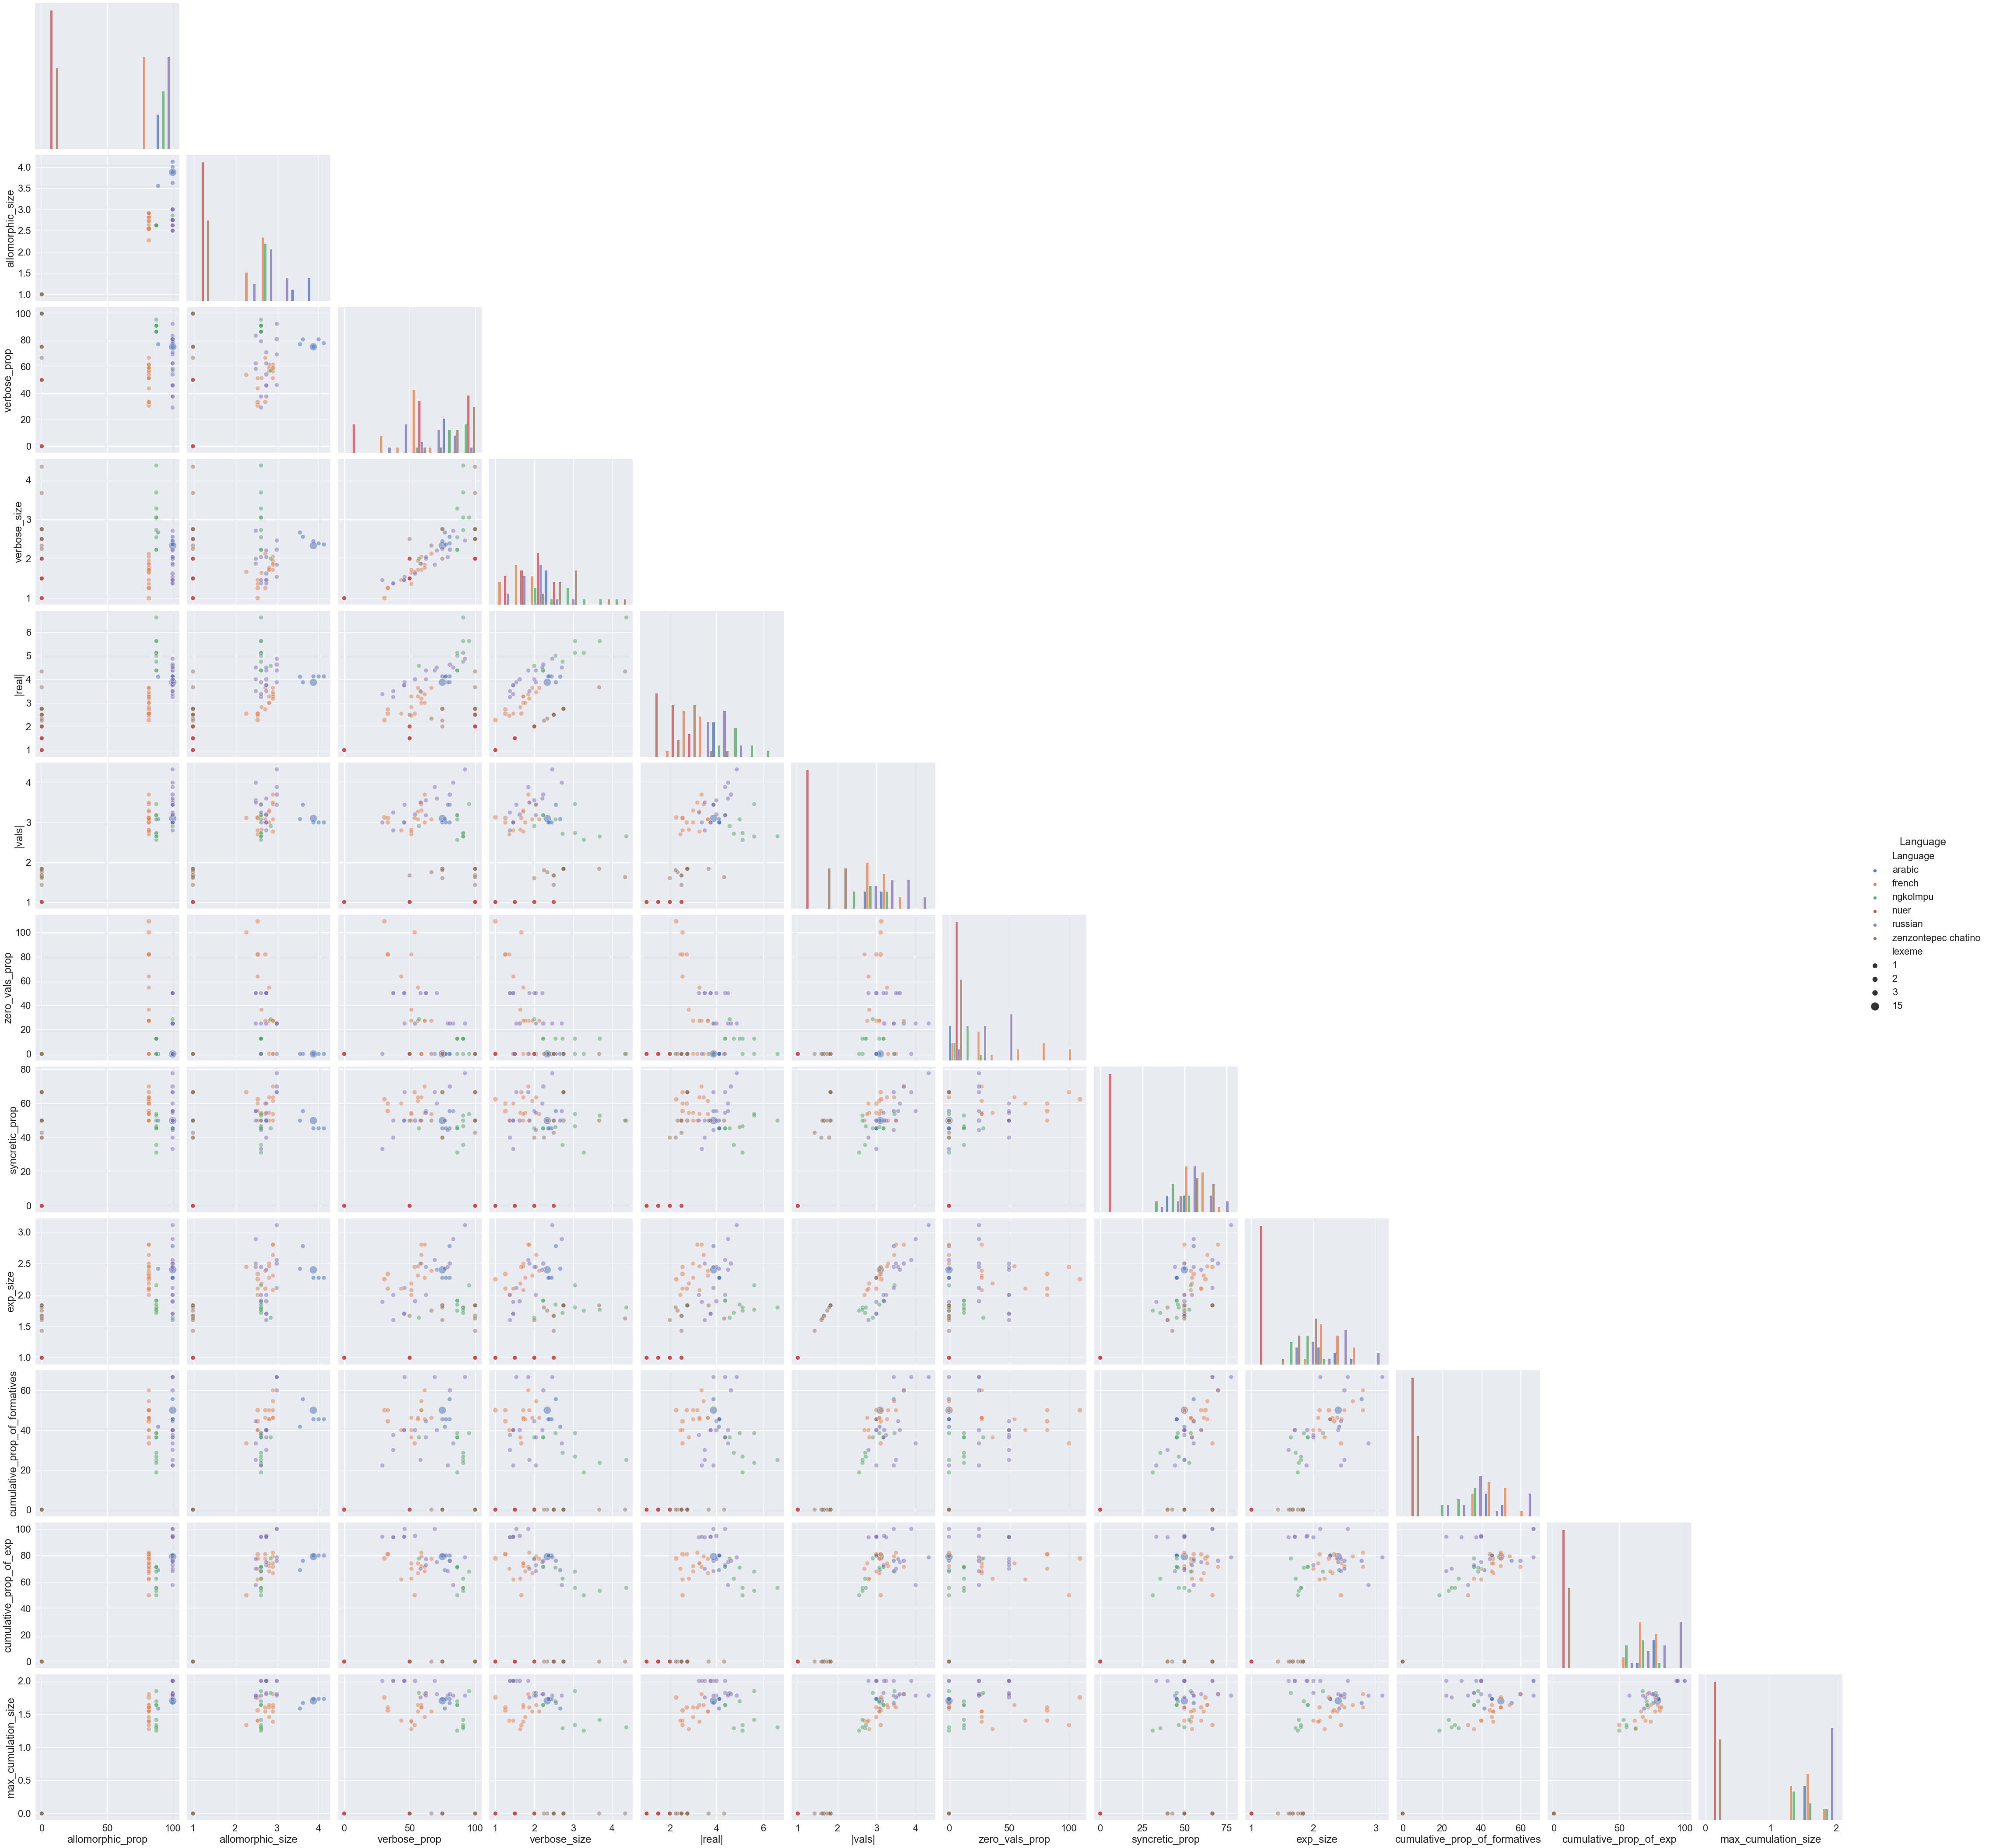

In [60]:

sns.set(font_scale=2)
sns.pairplot(data=coarse.reset_index(), height=5, hue="Language", corner=True, diag_kind="hist", diag_kws=dict(multiple="dodge", common_norm=False), plot_kws=dict(s=100, size=coarse_IC_size, sizes=(100,300), alpha=.5))

In [61]:
no_stems_IC

,index,lexeme,tier,slot,formative,dist,exponence,vals,|vals|,|exp|,cumulative,cumulative_cells,max_cumulation,maximum_possible_cumulation,Language,|cumulative|
0,0,danā,segmental,0,j,"[[prs, act, ind, 3, m, p], [prs, act, ind, 3, ...",m.3 3.p,3 m p,3,2,m.3 3.p,prs.act.ind.3.m.p prs.act.ind.3.f.p prs.act.in...,2,6,arabic,2
1,1,danā,segmental,0,n,"[[1, m/f, prs, act, ind, p]]",1.p,1 p,2,1,1.p,1.m/f.prs.act.ind.p,2,6,arabic,1
2,2,danā,segmental,0,t,"[[2, prs, act, ind, s, f], [prs, act, ind, 3, ...",s.f d.f 2,2 d f s,4,3,s.f d.f,prs.act.ind.3.s.f prs.act.ind.3.f.d 2.prs.act....,2,6,arabic,2
4,4,danā,segmental,2,iː,"[[2, prs, act, ind, s, f]]",2.s.f,2 f s,3,1,2.s.f,2.prs.act.ind.s.f,3,6,arabic,1
5,5,danā,segmental,2,uwaː,"[[prs, act, ind, 3, f, d], [prs, act, ind, 3, ...",d,d,1,1,NaN,NaN,0,6,arabic,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1109,143,ʔne⁰,segmental,2,k,[[cpl]],cpl,cpl,1,1,NaN,NaN,0,1,zenzontepec chatino,0
1110,144,ʔne⁰,segmental,3,a,"[[hab], [cpl]]",hab cpl,cpl hab,2,2,NaN,NaN,0,1,zenzontepec chatino,0
1111,145,ʔne⁰,segmental,3,e,[[prog]],prog,prog,1,1,NaN,NaN,0,1,zenzontepec chatino,0
1113,147,ʔne⁰,tone,0,⁰,[[hab]],hab,hab,1,1,NaN,NaN,0,1,zenzontepec chatino,0


## Per values & IC

In [62]:
cells_structure = paradigms_IC.groupby(["Language", "lexeme"])["cell"].agg(set)

In [63]:
vals_measures = multimerge(vals_IC.groupby(["Language", "lexeme", "vals"])[["|real|", "|allomorphic_sets|"]].sum(),
                                # Number of exponents expressing each value  & Number of allomorphic sets

                                vals_IC.groupby(["Language", "lexeme", "vals"]).apply(lambda g: len([cell for cell in cells_structure[g.name[:2]] if g.name[2] in cell])).rename("cells"),
                                # number of cells in which it occurs

                                vals_w_IC.groupby(["Language", "lexeme", "vals"])["|real_w|"].mean().rename("f_per_w"),
                                # Average number of formatives per word for this value

                                vals_w_IC[vals_w_IC["|real_w|"] == 0].groupby(["Language", "lexeme", "vals"]).size().rename("zeros_exps"),
                                # Number of zero exponents expressing it

                                vals_w_IC[vals_w_IC["|real_w|"] > 1].groupby(["Language", "lexeme", "vals"])["cell"].nunique().rename("verbose_cells"),
                                #Number of cells where v is verbosely expressed

                                vals_w_IC.groupby(["Language", "lexeme", "vals"]).apply(lambda x: x[["cell","form"]].drop_duplicates().shape[0]).rename("words"),
                                # words with the value

                                left_index=True, right_index=True, how="outer").fillna(0)


In [64]:
vals_measures

|real|  |allomorphic_sets|  cells   f_per_w  \
Language            lexeme  vals                                                
arabic              danā    1          2                   2      2  1.500000   
                            2          5                   4      5  3.200000   
                            3          4                   5      6  2.333333   
                            d          4                   2      3  3.666667   
                            f          4                   5      5  2.400000   
...                                  ...                 ...    ...       ...   
zenzontepec chatino yu¹kų²ʔ pot        1                   1      1  1.000000   
                            prog       4                   1      1  4.000000   
                    ʔne⁰    cpl        4                   1      1  4.000000   
                            hab        5                   1      1  5.000000   
                            prog       4                   1      1  4.000000   

                                  zeros_exps  verbose_cells  words  
Language            lexeme  vals                                    
arabic              danā    1            0.0            1.0      2  
                            2            0.0            5.0      5  
                            3            0.0            4.0      6  
                            d            0.0            3.0      3  
                            f            0.0            4.0      5  
...                                      ...            ...    ...  
zenzontepec chatino yu¹kų²ʔ pot          0.0            0.0      1  
                            prog         0.0            1.0      1  
                    ʔne⁰    cpl          0.0            1.0      1  
                            hab          0.0            1.0      1  
                            prog         0.0            1.0      1  

[531 rows x 7 columns]

In [65]:
vals_measures["ratio_allom_set"] = vals_measures["|allomorphic_sets|"] / vals_measures["words"]

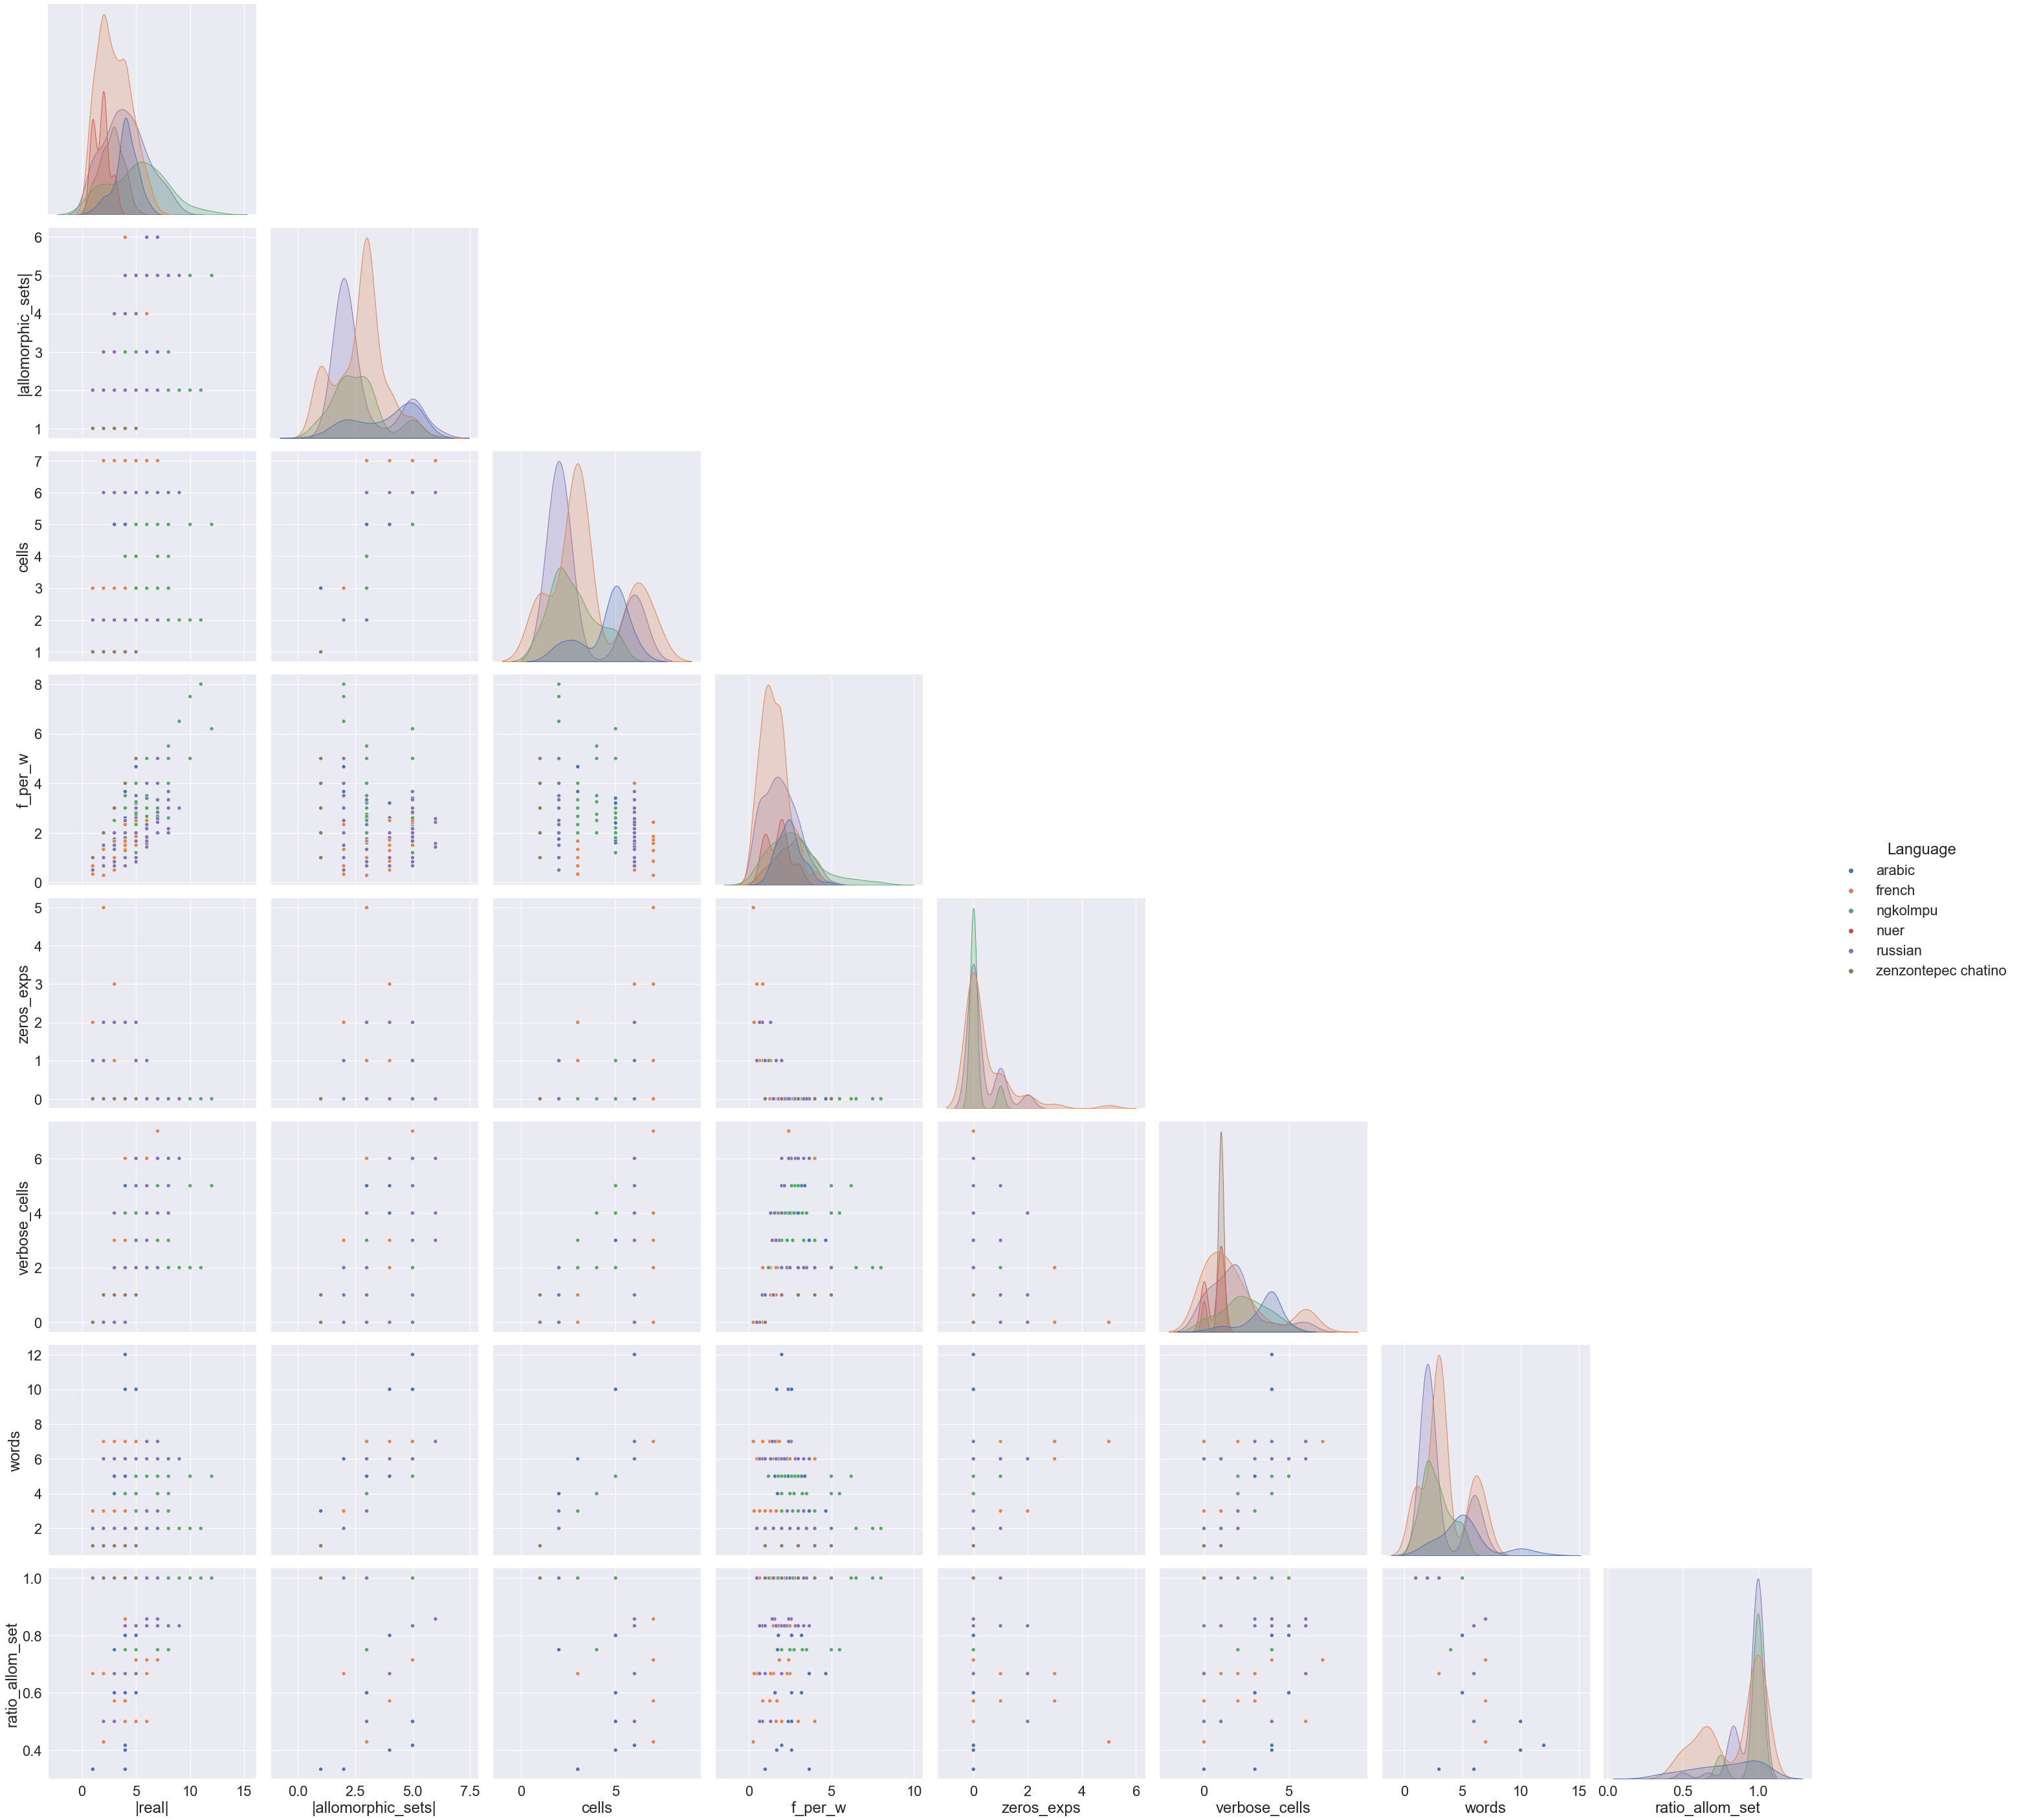

In [66]:

sns.set(font_scale=2)
sns.pairplot(data=vals_measures.reset_index(), height=5, hue="Language", corner=True) #plot_kws=dict(s=200, opacity=.3))

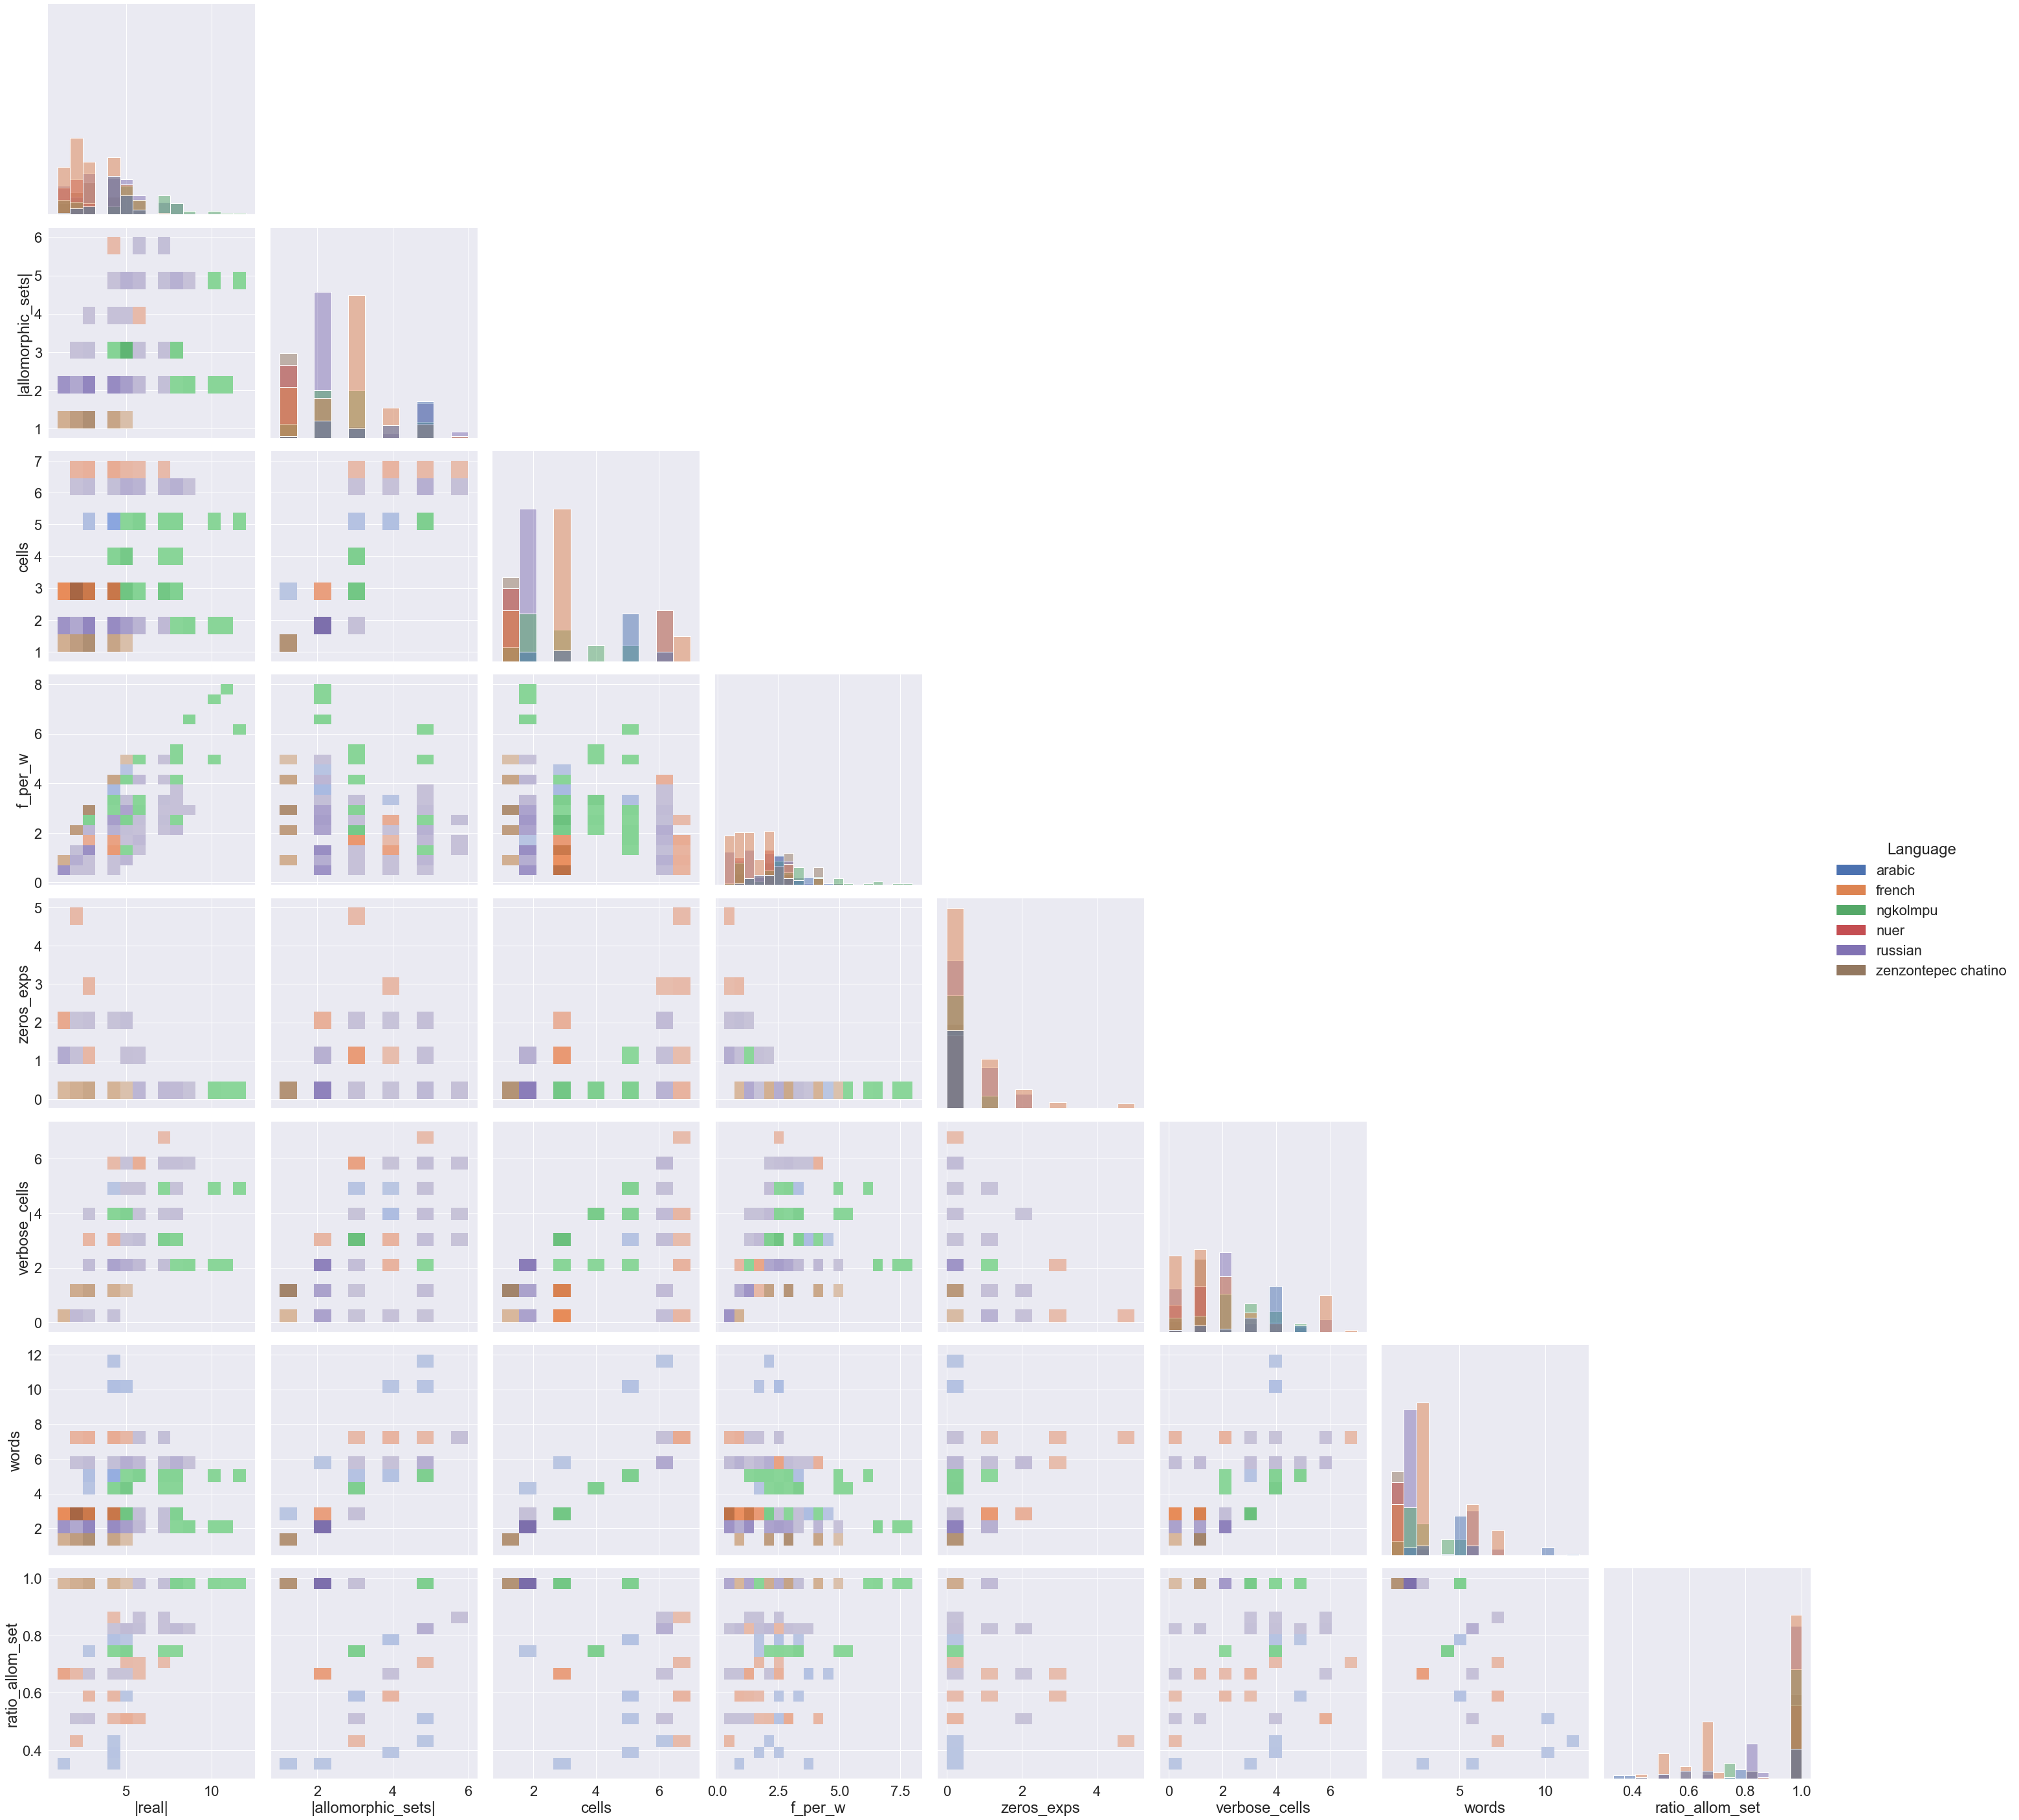

In [67]:

sns.pairplot(data=vals_measures.reset_index(), height=5, hue="Language", kind="hist", corner=True) #, plot_kws=dict(s=200, opacity=.3))